# 🔋⚡ EV 배터리 방전 × SMP 저가 예측 통합 파이프라인

## 프로젝트 개요

```
┌──────────────────────────────────────────────────────────────────────┐
│              통합 A → B → C → 시나리오 분석 파이프라인               │
├──────────────────┬───────────────────────────────────────────────────┤
│  Model A (TFT)   │ 제주 전력수요 24h 예측 (기상 + 사회 피처)        │
│  Model B (TFT)   │ 제주 SMP 24h 예측 (A 예측값 주입 → 연쇄 예측)   │
│  Model C (Stack) │ EV 배터리 10% SoC 도달 시간 예측 (분 단위)       │
├──────────────────┴───────────────────────────────────────────────────┤
│  🎯 핵심 시나리오                                                    │
│     SMP 저가 구간 예측 (Model B)  ×  EV 방전 시점 예측 (Model C)    │
│     → 두 조건이 겹치는 시간대 = "EV 충전 최적 타이밍" 알림 발사 🚨   │
└──────────────────────────────────────────────────────────────────────┘
```

### 시나리오 설명
- **SMP 저가**: Model B가 예측한 향후 24h 중 SMP가 임계값(예: 80 원/kWh) 이하인 시간대
- **EV 방전 임박**: Model C가 예측한 배터리 10% 도달 시간(분)이 해당 저가 구간과 겹치는 경우
- **알림 조건**: `방전 예상 시각 ∈ SMP 저가 구간` → 충전 권고 발송

## 0. 환경 설정

In [1]:
# ── 라이브러리 설치 (Colab 전용) ──────────────────────────────────────────
!pip install -q pytorch-forecasting pytorch-lightning
!pip install -q xgboost lightgbm shap optuna umap-learn scikit-learn
!apt-get install -y fonts-nanum -q
print("✅ 설치 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.7 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (37.3 M

In [2]:
# ── 공통 임포트 ────────────────────────────────────────────────────────────
import os, glob, warnings, subprocess, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta

# TFT (Model A, B)
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, LearningRateMonitor, ModelCheckpoint, StochasticWeightAveraging
)
from lightning.pytorch.loggers import CSVLogger
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, Baseline
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import QuantileLoss

# Model C (XGB + LGB Stacking)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
import optuna
import shap
import umap
import joblib

warnings.filterwarnings('ignore')
pl.seed_everything(42, workers=True)

# 한글 폰트
subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ 모든 라이브러리 임포트 완료")

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


✅ 모든 라이브러리 임포트 완료


In [3]:
import sys
import os
import platform
import subprocess
import pandas as pd
import numpy as np
import sklearn
import torch

# 노트북에서 사용된 핵심 라이브러리 목록
libraries = [
    "pandas", "numpy", "scikit-learn", "torch",
    "pytorch-forecasting", "pytorch-lightning",
    "xgboost", "lightgbm", "optuna", "shap",
    "umap-learn", "matplotlib", "seaborn"
]

print("="*50)
print("  [재현 환경 확인 결과]  ")
print("="*50)

# 1. 시스템 정보
print(f"파이썬 버전: {sys.version}")
print(f"운영체제: {platform.platform()}")

# 2. GPU 확인 (Model A, B 학습에 필수)
try:
    if torch.cuda.is_available():
        print(f"GPU 사용 가능: {torch.cuda.get_device_name(0)}")
    else:
        print("GPU 사용 불가 (CPU 모드)")
except:
    print("GPU 정보 확인 실패")

print("-"*50)
print("  [주요 패키지 버전]  ")

# 3. 개별 라이브러리 버전 체크
for lib in libraries:
    try:
        # 패키지 이름과 import 이름이 다른 경우 처리
        import_name = lib.replace("-", "_")
        if lib == "scikit-learn": import_name = "sklearn"
        elif lib == "umap-learn": import_name = "umap"

        module = __import__(import_name)
        version = getattr(module, "__version__", "버전 정보 없음")
        print(f"{lib:<20} : {version}")
    except ImportError:
        print(f"{lib:<20} : [미설치] - !pip install {lib} 필요")

print("-"*50)

  [재현 환경 확인 결과]  
파이썬 버전: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
운영체제: Linux-6.6.122+-x86_64-with-glibc2.35
GPU 사용 가능: Tesla T4
--------------------------------------------------
  [주요 패키지 버전]  
pandas               : 2.2.2
numpy                : 2.0.2
scikit-learn         : 1.6.1
torch                : 2.10.0+cu128
pytorch-forecasting  : 1.7.0
pytorch-lightning    : 2.6.1
xgboost              : 3.2.0
lightgbm             : 4.6.0
optuna               : 4.8.0
shap                 : 0.51.0
umap-learn           : 0.5.12
matplotlib           : 3.10.0
seaborn              : 0.13.2
--------------------------------------------------


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── 전역 설정 ──────────────────────────────────────────────────────────────
class Config:
    SEED = 42

    # ── 경로 ──
    BASE_PATH   = '/content/drive/MyDrive/ax_team/'
    SAVE_PATH   = BASE_PATH + 'ax_modeling/'
    PATH_A      = BASE_PATH + 'ax_data/model_a/model_a_data.csv'
    PATH_B      = BASE_PATH + 'ax_data/model_b/model_b_data.csv'
    PATH_C      = BASE_PATH + 'ax_data/model_c/model_c_data.csv'

    # ── TFT 공통 ──
    MAX_PRED_LEN    = 24        # 24h 예측
    MAX_ENC_LEN     = 24 * 7   # 7일 인코더
    BATCH_SIZE      = 32
    MAX_EPOCHS      = 100
    PATIENCE        = 15

    # ── Model C ──
    TARGET_C        = 'Target_Min_to_10'   # 배터리 10% 도달까지 남은 분
    TEST_SIZE_C     = 0.2
    VAL_SIZE_C      = 0.2
    N_TRIALS_C      = 100
    EARLY_STOP_C    = 50

    # ── 시나리오 임계값 ──
    SMP_LOW_THRESHOLD      = 80.0    # 원/kWh — 이 이하면 "저가" 판정
    DISCHARGE_WARN_MIN     = 60      # 방전까지 남은 시간(분)이 이 이하면 "방전 임박"
    SMP_LOW_PERCENTILE     = 25      # 데이터 하위 25%를 저가 임계값으로 동적 설정할 때 사용

os.makedirs(Config.SAVE_PATH, exist_ok=True)

def seed_everything(seed=Config.SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything()
print("✅ Config 설정 완료")

✅ Config 설정 완료


---
## 1. 데이터 로드 및 전처리
### 1-1. Model A / B 데이터

In [ ]:
def load_csv_safe(path):
    for enc in ['cp949', 'utf-8', 'euc-kr']:
        try:
            return pd.read_csv(path, encoding=enc)
        except (UnicodeDecodeError, FileNotFoundError):
            continue
    raise ValueError(f"읽기 실패: {path}")

def make_dummy_demand_data(n=8760):
    """Model A 더미 데이터 (파일 없을 때)"""
    np.random.seed(42)
    dates = pd.date_range('2023-01-01', periods=n, freq='H')
    df = pd.DataFrame({
        '날짜': dates.strftime('%Y-%m-%d'),
        '시간': dates.strftime('%H:00'),
        '전력수요': 400 + 100*np.sin(np.linspace(0, 4*np.pi, n)) + np.random.normal(0,20,n),
        '기온(°C)': 15 + 12*np.sin(np.linspace(-np.pi/2, 3.5*np.pi, n)) + np.random.normal(0,2,n),
        '풍속(m/s)': np.abs(np.random.normal(3, 1.5, n)),
        '습도(%)': np.random.uniform(40, 90, n),
        '일사(MJ/m2)': np.abs(np.random.normal(8, 5, n)),
        '전운량(10분위)': np.random.randint(0, 11, n).astype(float),
        '기온편차(°C)': np.random.normal(0, 2, n),
        '요일': dates.dayofweek.astype(str),
        '주말_유무': (dates.dayofweek >= 5).astype(str),
        '휴일_유무': '0',
        '총 생산지수': np.random.uniform(95, 105, n),
        '광업 및 제조업 생산지수': np.random.uniform(95, 105, n),
        '전기업 및 가스업 생산지수': np.random.uniform(95, 105, n),
        '내국인방문객수': np.random.uniform(3000, 10000, n),
        '외국인방문객수': np.random.uniform(100, 2000, n),
        '1시간전_수요': np.roll(400 + 100*np.sin(np.linspace(0, 4*np.pi, n)), 1),
        '전일_동시간_수요': np.roll(400 + 100*np.sin(np.linspace(0, 4*np.pi, n)), 24),
        '최근7일_평균_수요': np.roll(400 + 100*np.sin(np.linspace(0, 4*np.pi, n)), 168),
    })
    return df

def make_dummy_smp_data(n=8760):
    """Model B 더미 데이터 (파일 없을 때)"""
    np.random.seed(42)
    dates = pd.date_range('2023-01-01', periods=n, freq='H')
    smp_base = 120 + 40*np.sin(np.linspace(0, 4*np.pi, n)) + np.random.normal(0, 15, n)
    df = pd.DataFrame({
        '날짜': dates.strftime('%Y-%m-%d'),
        '시간': dates.strftime('%H:00'),
        'jeju_smp': smp_base,
        'mainland_smp': smp_base + np.random.normal(10, 5, n),
        'mainland_smp_lag_24h': np.roll(smp_base + np.random.normal(10,5,n), 24),
        'is_negative_smp': (smp_base < 0).astype(float),
        'peak_index': np.random.uniform(0.5, 1.5, n),
        'lag_smp_1h': np.roll(smp_base, 1),
        'lag_smp_24h': np.roll(smp_base, 24),
        'smp_rolling_24h_mean': pd.Series(smp_base).rolling(24, min_periods=1).mean().values,
        'predicted_demand': 400 + 100*np.sin(np.linspace(0, 4*np.pi, n)),
        'forecast_solar': np.abs(np.random.normal(50, 30, n)),
        'forecast_wind': np.abs(np.random.normal(30, 15, n)),
        'renewable_pen': np.random.uniform(10, 40, n),
        'net_load': 400 + 100*np.sin(np.linspace(0, 4*np.pi, n)) - 80,
        'temperature_forecast': 15 + 12*np.sin(np.linspace(-np.pi/2, 3.5*np.pi, n)),
        'precipitation_forecast': np.random.uniform(0, 30, n),
        'solar_radiation': np.abs(np.random.normal(8, 5, n)),
        'cloud_cover': np.random.uniform(0, 10, n),
        'wind_speed_forecast': np.abs(np.random.normal(3, 1.5, n)),
        'day_of_week': dates.dayofweek.astype(str),
        'is_weekend': (dates.dayofweek >= 5).astype(str),
        'is_holiday': '0',
        'holiday_type': 'none',
        'special_day_window': '0',
        'special_day_type': 'none',
        'special_day_offset': 0.0,
        'jeju_mainland_gap_lag_24h': np.random.normal(-10, 5, n),
        'lng_price_index': np.random.uniform(100, 130, n),
        'fuel_cost_unit': np.random.uniform(60, 90, n),
        'oil_price_dubai': np.random.uniform(70, 100, n),
        'usd_krw': np.random.uniform(1280, 1380, n),
        '최대전력_금년': np.random.uniform(700, 900, n),
        '공급예비력': np.random.uniform(100, 300, n),
        '공급예비율': np.random.uniform(10, 30, n),
    })
    return df


# ── 데이터 로드 ────────────────────────────────────────────────────────────
try:
    df_a = load_csv_safe(Config.PATH_A)
    print("✅ Model A 데이터 로드 성공")
except:
    print("⚠️  Model A: 더미 데이터 사용")
    df_a = make_dummy_demand_data()

try:
    df_b = load_csv_safe(Config.PATH_B)
    print("✅ Model B 데이터 로드 성공")
except:
    print("⚠️  Model B: 더미 데이터 사용")
    df_b = make_dummy_smp_data()

✅ Model A 데이터 로드 성공
✅ Model B 데이터 로드 성공


In [ ]:
# ── Model A 전처리 ─────────────────────────────────────────────────────────
df_a['datetime']     = pd.to_datetime(df_a['날짜'] + ' ' + df_a['시간'])
df_a                 = df_a.sort_values('datetime').reset_index(drop=True)
df_a['time_idx']     = np.arange(len(df_a))
df_a['group_id']     = 'jeju'
df_a['요일']          = df_a['요일'].astype(str)
df_a['주말_유무']      = df_a['주말_유무'].astype(str)
df_a['휴일_유무']      = df_a['휴일_유무'].astype(str)

# 피처 엔지니어링 — 냉난방 / 주기 피처
df_a['HDD']           = (18 - df_a['기온(°C)']).clip(lower=0)
df_a['CDD']           = (df_a['기온(°C)'] - 18).clip(lower=0)

df_a['CDD_sq']         = df_a['CDD'] ** 2                          # 폭염 비선형 효과
df_a['열대야']          = (df_a['기온(°C)'] >= 25).astype(int)      # 야간 고온 여부
df_a['폭염']            = (df_a['기온(°C)'] >= 33).astype(int)      # 폭염 플래그
df_a['기온_168h평균']   = df_a['기온(°C)'].rolling(168).mean().bfill()  # 1주 평균기온

df_a['체감온도']       = (13.12 + 0.6215*df_a['기온(°C)']
                          - 11.37*df_a['풍속(m/s)']**0.16
                          + 0.3965*df_a['기온(°C)']*df_a['풍속(m/s)']**0.16)
df_a['hour_sin']      = np.sin(2*np.pi*df_a['datetime'].dt.hour/24)
df_a['hour_cos']      = np.cos(2*np.pi*df_a['datetime'].dt.hour/24)
df_a['month_sin']     = np.sin(2*np.pi*df_a['datetime'].dt.month/12)
df_a['month_cos']     = np.cos(2*np.pi*df_a['datetime'].dt.month/12)
df_a['기온변화_24h']   = df_a['기온(°C)'].diff(24).bfill()
df_a['기온_72h평균']   = df_a['기온(°C)'].rolling(72).mean().bfill()
df_a['계절']           = df_a['datetime'].dt.month.map({
    12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',
    6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'
}).astype(str)

# ── Model B 전처리 ─────────────────────────────────────────────────────────
df_b['datetime']         = pd.to_datetime(df_b['날짜'] + ' ' + df_b['시간'])
df_b                     = df_b.sort_values('datetime').reset_index(drop=True)
df_b['time_idx']         = np.arange(len(df_b))
df_b['group_id']         = 'jeju'

cat_cols_b = ['day_of_week', 'is_weekend', 'is_holiday', 'holiday_type', 'special_day_window', 'special_day_type']
for col in cat_cols_b:
    if col in df_b.columns:
        df_b[col] = df_b[col].astype(str)

df_b['hour_sin']         = np.sin(2*np.pi*df_b['datetime'].dt.hour/24)
df_b['hour_cos']         = np.cos(2*np.pi*df_b['datetime'].dt.hour/24)
df_b['month_sin']        = np.sin(2*np.pi*df_b['datetime'].dt.month/12)
df_b['month_cos']        = np.cos(2*np.pi*df_b['datetime'].dt.month/12)
df_b['lag_smp_48h']      = df_b['jeju_smp'].shift(48).bfill()
df_b['lag_smp_168h']     = df_b['jeju_smp'].shift(168).bfill()
df_b['smp_roll_mean24']  = df_b['jeju_smp'].rolling(24, min_periods=1).mean().bfill()
df_b['smp_roll_std24']   = df_b['jeju_smp'].rolling(24, min_periods=1).std().bfill()
df_b['mainland_diff']    = df_b['jeju_smp'] - df_b['mainland_smp']
df_b['solar_wind_ratio'] = (df_b['forecast_solar'] /
                             (df_b['forecast_wind'] + 1e-8)).clip(upper=100)
# ── Model B predicted_demand / net_load / renewable_pen 클리닝 ─────────────
# SMP가 음수가 될 수 있는 구조 → inf/NaN 제거 필수
for _col in ['predicted_demand', 'net_load', 'renewable_pen']:
    if _col in df_b.columns:
        df_b[_col] = pd.to_numeric(df_b[_col], errors='coerce')
        df_b[_col] = df_b[_col].replace([np.inf, -np.inf], np.nan)
        df_b[_col] = df_b[_col].interpolate(method='linear').bfill().ffill().fillna(0)
print(f"Model A: {len(df_a):,}행  |  Model B: {len(df_b):,}행")
print(f"Model A 기간: {df_a['datetime'].min()} ~ {df_a['datetime'].max()}")
print(f"Model B 기간: {df_b['datetime'].min()} ~ {df_b['datetime'].max()}")


Model A: 16,056행  |  Model B: 16,056행
Model A 기간: 2024-06-01 00:00:00 ~ 2026-03-31 23:00:00
Model B 기간: 2024-06-01 00:00:00 ~ 2026-03-31 23:00:00


### 1-2. Model C 데이터 (EV 배터리 방전 예측)

In [ ]:
def load_and_preprocess_model_c(path):
    try:
        df = pd.read_csv(path)
        print("✅ Model C 데이터 로드 성공")
    except FileNotFoundError:
        print("⚠️  Model C: 더미 데이터 사용")
        np.random.seed(Config.SEED)
        n = 3000
        # SoC에 기반한 현실적 타겟 생성: 잔여 SoC가 높을수록 방전까지 오래 걸림
        soc = np.random.uniform(20, 95, n)
        soh = np.random.uniform(80, 100, n)
        energy_cons = np.random.uniform(5.0, 8.0, n)
        # 방전까지 남은 분 = (soc - 10) / energy_cons * capacity_factor * soh_factor
        target = ((soc - 10) / energy_cons) * (soh / 100) * np.random.uniform(8, 12, n)
        target = target.clip(5, 180)  # 5분 ~ 180분

        df = pd.DataFrame({
            'User_ID': [f'U_{i:05d}' for i in range(n)],
            'Current_SoC': soc,
            'Battery_SoH': soh,
            'Battery_Temp': np.random.uniform(5, 40, n),
            'Cumul_Mileage': np.random.uniform(10000, 150000, n),
            'Avg_Energy_Cons': energy_cons,
            'Speed_Variance': np.random.uniform(5, 30, n),
            'Daily_Dist_Avg': np.random.uniform(20, 100, n),
            'Departure_Std': np.random.uniform(0.1, 3.0, n),
            'Route_Elevation': np.random.uniform(100, 1000, n),
            'Ambient_Temp': np.random.uniform(-5, 35, n),
            'Precipitation': np.random.choice([0, 1], n, p=[0.8, 0.2]),
            'Traffic_Index': np.random.randint(1, 10, n),
            'Day_of_Week': np.random.randint(0, 7, n),
            'Plug_in_History': np.random.uniform(0.1, 1.0, n),
            'User_Min_SoC': np.random.uniform(10, 20, n),
            Config.TARGET_C: target
        })
    return df

def feature_engineering_c(df):
    df_fe = df.copy()
    df_fe['is_weekend']            = df_fe['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)
    df_fe['mock_hour']             = np.random.randint(0, 24, size=len(df_fe))
    df_fe['is_rush_hour']          = df_fe['mock_hour'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)
    df_fe['temp_efficiency_score'] = df_fe['Battery_Temp'].apply(
        lambda x: 0.8 if x < 5 else (0.9 if x > 35 else 1.0))
    df_fe['soh_adjusted_capacity'] = df_fe['Current_SoC'] * (df_fe['Battery_SoH'] / 100.0)
    df_fe['aggressive_driving']    = df_fe['Speed_Variance'] * df_fe['Avg_Energy_Cons']
    df_fe['traffic_energy_loss']   = df_fe['Traffic_Index'] * df_fe['Speed_Variance']
    df_fe['est_total_energy_used'] = df_fe['Cumul_Mileage'] / df_fe['Avg_Energy_Cons']
    df_fe['soc_temp_interaction']  = df_fe['Current_SoC'] * df_fe['Ambient_Temp']
    df_fe['user_avg_dist_ratio']   = df_fe['Daily_Dist_Avg'] / df_fe['Cumul_Mileage'].mean()
    # SoC 잔여량 기반 직접 추정값 (피처로 추가)
    df_fe['raw_discharge_estimate']= ((df_fe['Current_SoC'] - 10)
                                       / df_fe['Avg_Energy_Cons']
                                       * (df_fe['Battery_SoH'] / 100.0)
                                       * df_fe['temp_efficiency_score'] * 10)
    if 'User_ID' in df_fe.columns:
        df_fe.drop('User_ID', axis=1, inplace=True)
    return df_fe

df_c_raw = load_and_preprocess_model_c(Config.PATH_C)
df_c_fe  = feature_engineering_c(df_c_raw)
print(f"Model C: {len(df_c_fe):,}행, {len(df_c_fe.columns)}개 피처")
print(f"타겟 분포 — 평균: {df_c_fe[Config.TARGET_C].mean():.1f}분, "
      f"중앙값: {df_c_fe[Config.TARGET_C].median():.1f}분")

✅ Model C 데이터 로드 성공
Model C: 20,000행, 26개 피처
타겟 분포 — 평균: 70.1분, 중앙값: 63.4분


---
## 2. 탐색적 데이터 분석 (EDA)

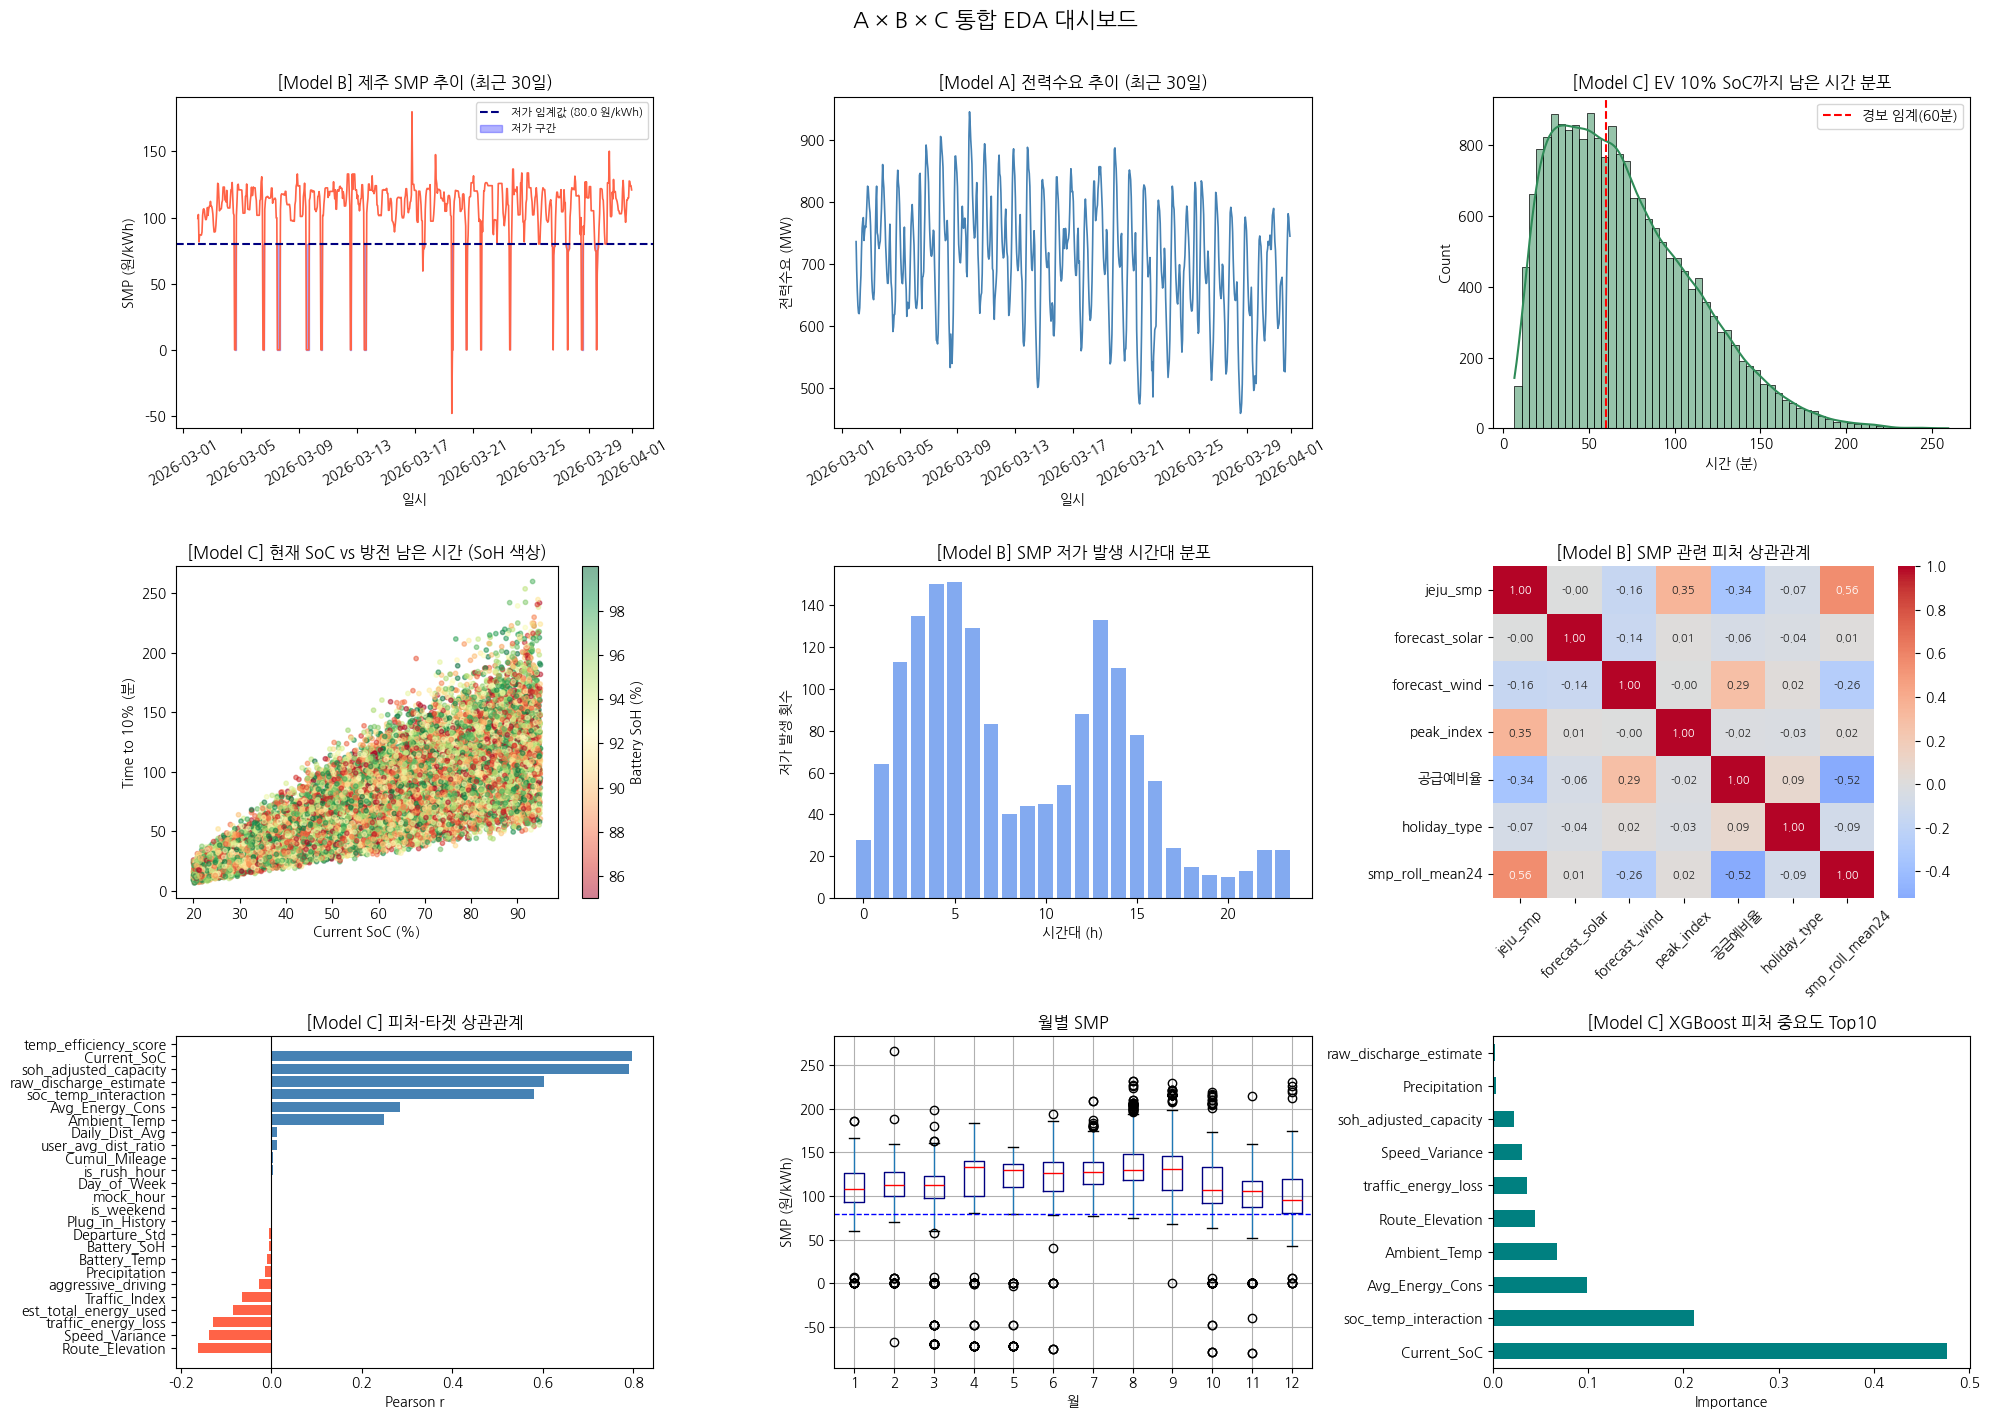

In [ ]:
fig = plt.figure(figsize=(20, 14))

# ── SMP 시계열 ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(df_b['datetime'][-720:], df_b['jeju_smp'][-720:], color='tomato', lw=1.2)
ax1.axhline(Config.SMP_LOW_THRESHOLD, color='navy', linestyle='--', lw=1.5,
            label=f'저가 임계값 ({Config.SMP_LOW_THRESHOLD} 원/kWh)')
ax1.fill_between(df_b['datetime'][-720:],
                 df_b['jeju_smp'][-720:], Config.SMP_LOW_THRESHOLD,
                 where=(df_b['jeju_smp'][-720:] < Config.SMP_LOW_THRESHOLD),
                 alpha=0.3, color='blue', label='저가 구간')
ax1.set_title('[Model B] 제주 SMP 추이 (최근 30일)', fontweight='bold')
ax1.set_xlabel('일시'); ax1.set_ylabel('SMP (원/kWh)')
ax1.legend(fontsize=8); ax1.tick_params(axis='x', rotation=30)

# ── 전력수요 시계열 ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(df_a['datetime'][-720:], df_a['전력수요'][-720:], color='steelblue', lw=1.2)
ax2.set_title('[Model A] 전력수요 추이 (최근 30일)', fontweight='bold')
ax2.set_xlabel('일시'); ax2.set_ylabel('전력수요 (MW)')
ax2.tick_params(axis='x', rotation=30)

# ── EV 방전 시간 분포 ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
sns.histplot(df_c_fe[Config.TARGET_C], kde=True, color='seagreen', ax=ax3)
ax3.axvline(Config.DISCHARGE_WARN_MIN, color='red', linestyle='--', lw=1.5,
            label=f'경보 임계({Config.DISCHARGE_WARN_MIN}분)')
ax3.set_title('[Model C] EV 10% SoC까지 남은 시간 분포', fontweight='bold')
ax3.set_xlabel('시간 (분)'); ax3.legend()

# ── SoC vs 방전시간 산점도 ─────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
sc = ax4.scatter(df_c_fe['Current_SoC'], df_c_fe[Config.TARGET_C],
                 c=df_c_fe['Battery_SoH'], cmap='RdYlGn', alpha=0.5, s=10)
plt.colorbar(sc, ax=ax4, label='Battery SoH (%)')
ax4.set_title('[Model C] 현재 SoC vs 방전 남은 시간 (SoH 색상)', fontweight='bold')
ax4.set_xlabel('Current SoC (%)'); ax4.set_ylabel('Time to 10% (분)')

# ── SMP 저가 시간대별 분포 ─────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
df_b_low = df_b[df_b['jeju_smp'] < Config.SMP_LOW_THRESHOLD]
if 'datetime' in df_b_low.columns:
    hour_counts = df_b_low['datetime'].dt.hour.value_counts().sort_index()
    ax5.bar(hour_counts.index, hour_counts.values, color='cornflowerblue', alpha=0.8)
ax5.set_title('[Model B] SMP 저가 발생 시간대 분포', fontweight='bold')
ax5.set_xlabel('시간대 (h)'); ax5.set_ylabel('저가 발생 횟수')

# ── 상관관계 — Model B 주요 피처 ───────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
corr_cols = ['jeju_smp', 'forecast_solar', 'forecast_wind', 'peak_index',   # 수정 필요
             '공급예비율', 'holiday_type', 'smp_roll_mean24']
corr_cols = [c for c in corr_cols if c in df_b.columns]
corr_mat = df_b[corr_cols].corr()
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax6, annot_kws={'size': 8})
ax6.set_title('[Model B] SMP 관련 피처 상관관계', fontweight='bold')
ax6.tick_params(axis='x', rotation=45)

# ── Model C 상관관계 ────────────────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
num_cols_c = df_c_fe.select_dtypes(include=[np.number]).columns
corr_c = df_c_fe[num_cols_c].corr()[Config.TARGET_C].drop(Config.TARGET_C).sort_values()
colors_c = ['tomato' if v < 0 else 'steelblue' for v in corr_c]
ax7.barh(corr_c.index, corr_c.values, color=colors_c)
ax7.axvline(0, color='black', lw=0.8)
ax7.set_title('[Model C] 피처-타겟 상관관계', fontweight='bold')
ax7.set_xlabel('Pearson r')

# ── SMP 월별 박스플롯 ────────────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
df_b['month'] = df_b['datetime'].dt.month
df_b.boxplot(column='jeju_smp', by='month', ax=ax8,
             boxprops=dict(color='navy'), medianprops=dict(color='red'))
ax8.axhline(Config.SMP_LOW_THRESHOLD, color='blue', linestyle='--', lw=1, label='저가 임계')
ax8.set_title('[Model B] 월별 SMP 분포', fontweight='bold')
ax8.set_xlabel('월'); ax8.set_ylabel('SMP (원/kWh)')
plt.sca(ax8); plt.title('월별 SMP'); plt.suptitle('')

# ── 피처 중요도 사전 분석 (빠른 XGB) ───────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
X_quick = df_c_fe.drop(Config.TARGET_C, axis=1)
y_quick = df_c_fe[Config.TARGET_C]
quick_model = xgb.XGBRegressor(n_estimators=50, max_depth=4, random_state=42, verbosity=0)
quick_model.fit(X_quick, y_quick)
fi = pd.Series(quick_model.feature_importances_, index=X_quick.columns).nlargest(10)
fi.plot(kind='barh', ax=ax9, color='teal')
ax9.set_title('[Model C] XGBoost 피처 중요도 Top10', fontweight='bold')
ax9.set_xlabel('Importance')

plt.suptitle('A × B × C 통합 EDA 대시보드', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. TFT 공통 설정 (Model A / B)

In [ ]:
# ── 피처 정의 ──────────────────────────────────────────────────────────────
KNOWN_CATS_A  = ['요일', '주말_유무', '휴일_유무', '계절']
KNOWN_REALS_A = ['time_idx', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                 '기온(°C)', '풍속(m/s)', '습도(%)', '일사(MJ/m2)',
                 '전운량(10분위)', '기온편차(°C)',
                 'HDD', 'CDD', '체감온도', '기온변화_24h', '기온_72h평균','CDD_sq', '열대야', '폭염', '기온_168h평균']
UNK_REALS_A   = ['전력수요', '총 생산지수', '광업 및 제조업 생산지수',
                 '전기업 및 가스업 생산지수',
                 '내국인방문객수', '외국인방문객수',
                 '1시간전_수요', '전일_동시간_수요', '최근7일_평균_수요']

KNOWN_CATS_B  = ['day_of_week', 'is_weekend', 'is_holiday', 'holiday_type',
                 'special_day_window', 'special_day_type']
KNOWN_REALS_B = ['time_idx', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                 'predicted_demand', 'renewable_pen', 'net_load', 'solar_wind_ratio',
                 'temperature_forecast', 'forecast_solar', 'forecast_wind',
                 'precipitation_forecast', 'solar_radiation', 'cloud_cover',
                 'wind_speed_forecast', 'special_day_offset', 'jeju_mainland_gap_lag_24h']
UNK_REALS_B   = ['jeju_smp', 'mainland_smp', 'mainland_smp_lag_24h', 'mainland_diff',
                 'is_negative_smp', 'peak_index', 'lag_smp_1h', 'lag_smp_24h',
                 'lag_smp_48h', 'lag_smp_168h',
                 'smp_rolling_24h_mean', 'smp_roll_mean24', 'smp_roll_std24',
                 'lng_price_index', 'fuel_cost_unit', 'oil_price_dubai', 'usd_krw',
                 '최대전력_금년', '공급예비력', '공급예비율']

def validate_features(df, known_cats, known_reals, unk_reals, name):
    all_feats = known_cats + known_reals + unk_reals
    missing = [f for f in all_feats if f not in df.columns]
    if missing:
        print(f"⚠️  [{name}] 없는 피처: {missing}")
    else:
        print(f"✅  [{name}] 피처 검증 완료 ({len(all_feats)}개 OK)")

validate_features(df_a, KNOWN_CATS_A, KNOWN_REALS_A, UNK_REALS_A, 'Model A')
validate_features(df_b, KNOWN_CATS_B, KNOWN_REALS_B, UNK_REALS_B, 'Model B')

# ── 체크포인트 콜백 ─────────────────────────────────────────────────────────
checkpoint_a = ModelCheckpoint(
    dirpath=Config.SAVE_PATH,
    filename='best_model_a-{val_loss:.2f}',  # {fold} 제거
    monitor='val_loss', mode='min', save_top_k=3, verbose=True
)
checkpoint_b = ModelCheckpoint(dirpath=Config.SAVE_PATH, filename='best_model_b',
                               monitor='val_loss', mode='min', save_top_k=1, verbose=True)

✅  [Model A] 피처 검증 완료 (33개 OK)
✅  [Model B] 피처 검증 완료 (44개 OK)


---
## 4. Sliding Window CV + 전체 학습 (Model A / B)

In [ ]:
def create_sliding_window_folds(df, time_col, train_size, gap, val_size, step):
    t_min  = int(df[time_col].min())
    t_max  = int(df[time_col].max())
    total  = t_max - t_min + 1
    folds, k, start = [], 0, 0
    while start + train_size + gap + val_size <= total:
        train_end = start + train_size
        val_start = train_end + gap
        val_end   = val_start + val_size
        train_df  = df[df[time_col].between(t_min+start,     t_min+train_end-1)].copy()
        val_df    = df[df[time_col].between(t_min+val_start, t_min+val_end-1)].copy()
        train_df  = train_df.interpolate(method='linear', limit_direction='forward').bfill()
        val_df    = val_df.interpolate(method='linear', limit_direction='forward').bfill()
        folds.append({'fold': k, 'train_df': train_df, 'val_df': val_df,
                      'train_range': (t_min+start, t_min+train_end-1),
                      'val_range': (t_min+val_start, t_min+val_end-1)})
        start += step; k += 1
    print(f"  총 {len(folds)}개 fold  (train={train_size}/gap={gap}/val={val_size}/step={step})")
    return folds

train_size_cv = 24 * 90
gap_cv        = Config.MAX_PRED_LEN
val_size_cv   = 24 * 14
step_cv       = 1000

print("[Model A]", end=" ")
folds_a = create_sliding_window_folds(df_a, 'time_idx', train_size_cv, gap_cv, val_size_cv, step_cv)
print("[Model B]", end=" ")
folds_b = create_sliding_window_folds(df_b, 'time_idx', train_size_cv, gap_cv, val_size_cv, step_cv)

[Model A]   총 14개 fold  (train=2160/gap=24/val=336/step=1000)
[Model B]   총 14개 fold  (train=2160/gap=24/val=336/step=1000)


In [ ]:
from torch.utils.data import WeightedRandomSampler

def make_tft_a(ds):
    return TemporalFusionTransformer.from_dataset(
        ds,
        learning_rate=5e-4,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.1,
        hidden_continuous_size=32,
        output_size=7,
        loss=QuantileLoss(),
        reduce_on_plateau_patience=3,
        log_interval=10,
        weight_decay=1e-4,
    )

def make_tft_b(ds):
    return TemporalFusionTransformer.from_dataset(
        ds,
        learning_rate=5e-4,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.15,
        hidden_continuous_size=32,
        output_size=7,
        loss=QuantileLoss(),
        reduce_on_plateau_patience=3,
        log_interval=10,
        weight_decay=1e-4,
    )

def run_cv(folds, df, known_cats, known_reals, unk_reals, target, make_fn, model_name,
           normalizer=None):
    if normalizer is None:
        normalizer = GroupNormalizer(groups=['group_id'], transformation='softplus')
    cv_scores = []
    for fold_info in folds:
        k        = fold_info['fold']
        train_df = fold_info['train_df'].copy()
        val_df   = fold_info['val_df'].copy()
        offset   = int(train_df['time_idx'].min())
        train_df['time_idx'] -= offset
        val_df['time_idx']   -= offset
        try:
            tr_ds = TimeSeriesDataSet(
                train_df, time_idx='time_idx', target=target, group_ids=['group_id'],
                min_encoder_length=Config.MAX_ENC_LEN//2, max_encoder_length=Config.MAX_ENC_LEN,
                min_prediction_length=1, max_prediction_length=Config.MAX_PRED_LEN,
                static_categoricals=['group_id'],
                time_varying_known_categoricals=known_cats,
                time_varying_known_reals=known_reals,
                time_varying_unknown_reals=unk_reals,
                target_normalizer=normalizer,
                allow_missing_timesteps=True,
                categorical_encoders={c: NaNLabelEncoder(add_nan=True)
                                      for c in known_cats + ['group_id']},
            )
            full_fold = pd.concat([train_df, val_df]).sort_values('time_idx')
            val_ds    = TimeSeriesDataSet.from_dataset(tr_ds, full_fold, predict=True, stop_randomization=True)

            # ── Model A: 여름 구간 가중치 샘플링 ──────────────────────────
            if 'Model_A' in model_name:
                # 1. tr_ds.index에서 각 샘플(윈도우)이 끝나는 지점의 '행 번호'를 가져옵니다.
                # 'index_end'는 라이브러리 내부에서 데이터의 위치를 추적하는 표준 필드입니다.
                sample_end_positions = tr_ds.index['index_end'].values

                # 2. train_df에서 해당 위치의 행들을 찾아 월(month) 정보를 추출합니다.
                # .iloc를 사용해 물리적 위치로 접근하므로 컬럼명 이슈를 완벽히 피합니다.
                sample_months = train_df['datetime'].iloc[sample_end_positions].dt.month.values

                # 3. 여름(6, 7, 8월)에 해당하는 샘플에 가중치 3.0 부여
                weights = [3.0 if m in [6, 7, 8] else 1.0 for m in sample_months]

                # 4. 샘플러 생성 및 DataLoader 설정 (shuffle=False 필수)
                sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
                tr_dl = tr_ds.to_dataloader(train=True, batch_size=Config.BATCH_SIZE,
                                             num_workers=2, sampler=sampler, shuffle=False)
            else:
                tr_dl = tr_ds.to_dataloader(train=True, batch_size=Config.BATCH_SIZE, num_workers=2)

            val_dl = val_ds.to_dataloader(train=False, batch_size=Config.BATCH_SIZE*2, num_workers=2)

            trainer = pl.Trainer(
                max_epochs=Config.MAX_EPOCHS, accelerator='auto', gradient_clip_val=0.1,
                enable_progress_bar=False, enable_model_summary=False,
                callbacks=[EarlyStopping('val_loss', patience=Config.PATIENCE,
                                         min_delta=1e-4, mode='min')],
                logger=CSVLogger('logs', name=f'{model_name}_fold{k}'),
            )
            trainer.fit(make_fn(tr_ds), tr_dl, val_dl)
            loss = trainer.callback_metrics.get('val_loss', torch.tensor(float('nan'))).item()
            cv_scores.append(loss)
            print(f"  [{model_name} Fold {k:2d}] loss={loss:.4f}")
        except Exception as e:
            print(f"  [{model_name} Fold {k}] 건너뜀 — {e}")
    print(f"\n✅ {model_name} CV: 평균={np.nanmean(cv_scores):.4f} ± {np.nanstd(cv_scores):.4f}")
    return cv_scores

print("── Model A Sliding Window CV ──")
cv_scores_a = run_cv(
    folds_a, df_a, KNOWN_CATS_A, KNOWN_REALS_A, UNK_REALS_A,
    '전력수요', make_tft_a, 'Model_A',
    normalizer=GroupNormalizer(groups=['group_id'], transformation='softplus')
)

print("\n── Model B Sliding Window CV ──")
cv_scores_b = run_cv(
    folds_b, df_b, KNOWN_CATS_B, KNOWN_REALS_B, UNK_REALS_B,
    'jeju_smp', make_tft_b, 'Model_B',
    normalizer=GroupNormalizer(groups=['group_id'])
)

── Model A Sliding Window CV ──


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  [Model_A Fold  0] loss=14.6088


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  [Model_A Fold  1] loss=13.4052


...

  [Model_B Fold 11] loss=18.6425


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  [Model_B Fold 12] loss=5.1155


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  [Model_B Fold 13] loss=22.7058

✅ Model_B CV: 평균=12.9008 ± 8.8244


In [ ]:
import torch
torch.use_deterministic_algorithms(True, warn_only=True)

def full_train(df, known_cats, known_reals, unk_reals, target, make_fn,
               checkpoint_cb, model_name, normalizer=None):
    if normalizer is None:
        normalizer = GroupNormalizer(groups=['group_id'], transformation='softplus')

    df = df.interpolate().bfill()
    cutoff = df['time_idx'].max() - Config.MAX_PRED_LEN
    train_df = df[df.time_idx <= cutoff].copy()
    val_df = df.copy()

    training = TimeSeriesDataSet(
        train_df, time_idx='time_idx', target=target, group_ids=['group_id'],
        min_encoder_length=Config.MAX_ENC_LEN//2, max_encoder_length=Config.MAX_ENC_LEN,
        min_prediction_length=1, max_prediction_length=Config.MAX_PRED_LEN,
        static_categoricals=['group_id'],
        time_varying_known_categoricals=known_cats,
        time_varying_known_reals=known_reals,
        time_varying_unknown_reals=unk_reals,
        target_normalizer=normalizer,
        categorical_encoders={c: NaNLabelEncoder(add_nan=True)
                               for c in known_cats + ['group_id']},
    )

    # 1. Validation 데이터셋 및 DataLoader 생성 (누락 방지)
    validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=True, stop_randomization=True)
    val_dl = validation.to_dataloader(train=False, batch_size=Config.BATCH_SIZE * 2, num_workers=2)

    # 2. Model_A 전용 샘플링 로직 및 tr_dl 생성
    if 'Model_A' in model_name:
        sample_end_positions = training.index['index_end'].values
        sample_months = train_df['datetime'].iloc[sample_end_positions].dt.month.values

        weights = [3.0 if m in [6, 7, 8] else 1.0 for m in sample_months]
        sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

        tr_dl = training.to_dataloader(train=True, batch_size=Config.BATCH_SIZE,
                                        num_workers=2, sampler=sampler, shuffle=False)
    else:
        # Model_B 등 다른 모델을 위한 기본 DataLoader (누락 수정)
        tr_dl = training.to_dataloader(train=True, batch_size=Config.BATCH_SIZE, num_workers=2)

    # 3. 모델 정의 및 SWA 설정
    model = make_fn(training)
    swa = StochasticWeightAveraging(swa_lrs=1e-4, swa_epoch_start=0.6)

    trainer = pl.Trainer(
        max_epochs=Config.MAX_EPOCHS, accelerator='auto', gradient_clip_val=0.1,
        callbacks=[EarlyStopping('val_loss', patience=Config.PATIENCE, mode='min'),
                   LearningRateMonitor(), checkpoint_cb, swa],
        logger=CSVLogger('logs', name=f'{model_name}_final'),
    )

    # 학습 시작
    trainer.fit(model, tr_dl, val_dl)

    print(f"✅ {model_name} 전체 학습 완료")
    print(f"   베스트 체크포인트: {checkpoint_cb.best_model_path}")
    print(f"   베스트 val_loss : {checkpoint_cb.best_model_score:.6f}")

    return model, training, val_df, tr_dl, val_dl

print("── Model A 전체 학습 ──")
tft_a, training_a, val_base_a, train_dl_a, val_dl_a = full_train(
    df_a, KNOWN_CATS_A, KNOWN_REALS_A, UNK_REALS_A,
    '전력수요', make_tft_a, checkpoint_a, 'Model_A',
    normalizer=GroupNormalizer(groups=['group_id'], transformation='softplus')
)

print("\n── Model B 전체 학습 ──")
tft_b, training_b, val_base_b, train_dl_b, val_dl_b = full_train(
    df_b, KNOWN_CATS_B, KNOWN_REALS_B, UNK_REALS_B,
    'jeju_smp', make_tft_b, checkpoint_b, 'Model_B',
    normalizer=GroupNormalizer(groups=['group_id'])
)

── Model A 전체 학습 ──


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     80 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.9 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  7.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  232 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  154 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 600 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 600 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 932                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    109 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.5 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  7.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  320 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  139 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 673 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 673 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 1057                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Epoch 0, global step 501: 'val_loss' reached 5.87790 (best 5.87790), saving model to '/content/drive/MyDrive/ax_team/ax_modeling/best_model_b.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 501: 'val_loss' reached 5.87790 (best 5.87790), saving model to '/content/drive/MyDrive/ax_team/ax_modeling/best_model_b.ckpt' as top 1
INFO: Epoch 1, global step 1002: 'val_loss' reached 4.78255 (best 4.78255), saving model to '/content/drive/MyDrive/ax_team/ax_modeling/best_model_b.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 1002: 'val_loss' reached 4.78255 (best 4.78255), saving model to '/content/drive/MyDrive/ax_team/ax_modeling/best_model_b.ckpt' as top 1
INFO: Epoch 2, global step 1503: 'val_loss' reached 2.94046 (best 2.94046), saving model to '/content/drive/MyDrive/ax_team/ax_modeling/best_model_b.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 2, global step 1503: 'val_loss' reached 2.94046 (best 2.940

✅ Model_B 전체 학습 완료
   베스트 체크포인트: /content/drive/MyDrive/ax_team/ax_modeling/best_model_b.ckpt
   베스트 val_loss : 2.940456


---
## 5. Model C 학습 — EV 배터리 방전 예측 (XGBoost + LightGBM Stacking)

In [ ]:
X_c = df_c_fe.drop(Config.TARGET_C, axis=1)
y_c = df_c_fe[Config.TARGET_C]

X_temp_c, X_test_c, y_temp_c, y_test_c = train_test_split(
    X_c, y_c, test_size=Config.TEST_SIZE_C, random_state=Config.SEED)
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_temp_c, y_temp_c, test_size=Config.VAL_SIZE_C, random_state=Config.SEED)

scaler_c = RobustScaler()
X_train_cs = pd.DataFrame(scaler_c.fit_transform(X_train_c), columns=X_train_c.columns)
X_val_cs   = pd.DataFrame(scaler_c.transform(X_val_c),   columns=X_val_c.columns)
X_test_cs  = pd.DataFrame(scaler_c.transform(X_test_c),  columns=X_test_c.columns)

print(f"Train: {X_train_cs.shape}, Val: {X_val_cs.shape}, Test: {X_test_cs.shape}")

Train: (12800, 25), Val: (3200, 25), Test: (4000, 25)


In [ ]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

def objective_xgb_c(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': Config.SEED, 'early_stopping_rounds': Config.EARLY_STOP_C, 'verbosity': 0
    }
    m = xgb.XGBRegressor(**params)
    m.fit(X_train_cs, y_train_c, eval_set=[(X_val_cs, y_val_c)], verbose=False)
    return root_mean_squared_error(y_val_c, m.predict(X_val_cs))

def objective_lgb_c(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': Config.SEED, 'verbose': -1
    }
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train_cs, y_train_c, eval_set=[(X_val_cs, y_val_c)],
          callbacks=[lgb.early_stopping(Config.EARLY_STOP_C, verbose=False)])
    return root_mean_squared_error(y_val_c, m.predict(X_val_cs))

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("[*] XGBoost Optuna 튜닝...")
study_xgb_c = optuna.create_study(direction='minimize')
study_xgb_c.optimize(objective_xgb_c, n_trials=Config.N_TRIALS_C)
print(f"  XGB Best RMSE: {study_xgb_c.best_value:.4f}")

print("[*] LightGBM Optuna 튜닝...")
study_lgb_c = optuna.create_study(direction='minimize')
study_lgb_c.optimize(objective_lgb_c, n_trials=Config.N_TRIALS_C)
print(f"  LGB Best RMSE: {study_lgb_c.best_value:.4f}")

best_xgb_c = xgb.XGBRegressor(**study_xgb_c.best_params, random_state=Config.SEED)
best_lgb_c = lgb.LGBMRegressor(**study_lgb_c.best_params, random_state=Config.SEED)

print("[*] Stacking Ensemble 구축 (Meta: Ridge)...")
stacking_c = StackingRegressor(
    estimators=[('xgb', best_xgb_c), ('lgb', best_lgb_c)],
    final_estimator=Ridge(alpha=1.0), cv=5
)
stacking_c.fit(X_train_cs, y_train_c)
print("✅ Model C 앙상블 학습 완료")

# 저장
joblib.dump(stacking_c, os.path.join(Config.SAVE_PATH, 'model_c_stacking.pkl'))
joblib.dump(scaler_c,   os.path.join(Config.SAVE_PATH, 'model_c_scaler.pkl'))

[*] XGBoost Optuna 튜닝...
  XGB Best RMSE: 3.1474
[*] LightGBM Optuna 튜닝...
  LGB Best RMSE: 3.1451
[*] Stacking Ensemble 구축 (Meta: Ridge)...
✅ Model C 앙상블 학습 완료


['/content/drive/MyDrive/ax_team/ax_modeling/model_c_scaler.pkl']

---
## 6. 통합 모델 평가

In [ ]:
tft_a = TemporalFusionTransformer.load_from_checkpoint(checkpoint_a.best_model_path)
tft_b = TemporalFusionTransformer.load_from_checkpoint(checkpoint_b.best_model_path)
tft_a.eval()
tft_b.eval()
print("✅ Best 체크포인트 로드 완료 — 시나리오 실행 준비")

✅ Best 체크포인트 로드 완료 — 시나리오 실행 준비


In [ ]:
# ── Model A 평가 ────────────────────────────────────────────────────────────
raw_a  = tft_a.predict(val_dl_a, mode='raw', return_x=True)
pred_a = raw_a.output.prediction[:, :, 3].detach().cpu().numpy().flatten()
true_a = raw_a.x['decoder_target'].detach().cpu().numpy().flatten()
mape_a = mean_absolute_percentage_error(true_a, pred_a) * 100
rmse_a = root_mean_squared_error(true_a, pred_a)
mae_a  = mean_absolute_error(true_a, pred_a)
status_a = '✅' if mape_a <= 5 else '⚠️'

# ── Model B 평가 ────────────────────────────────────────────────────────────
raw_b  = tft_b.predict(val_dl_b, mode='raw', return_x=True)
pred_b = raw_b.output.prediction[:, :, 3].detach().cpu().numpy().flatten()
true_b = raw_b.x['decoder_target'].detach().cpu().numpy().flatten()
mape_b = mean_absolute_percentage_error(true_b, pred_b) * 100
rmse_b = root_mean_squared_error(true_b, pred_b)
mae_b  = mean_absolute_error(true_b, pred_b)
status_b = '✅' if mape_b <= 10 else '⚠️'

# ── Model C 평가 ────────────────────────────────────────────────────────────
pred_c = stacking_c.predict(X_test_cs)
mape_c = mean_absolute_percentage_error(y_test_c, pred_c) * 100
rmse_c = root_mean_squared_error(y_test_c, pred_c)
mae_c  = mean_absolute_error(y_test_c, pred_c)
r2_c   = r2_score(y_test_c, pred_c)
status_c = '✅' if mape_c <= 15 else '⚠️'

# ── 파이프라인(A→B) 평가 ────────────────────────────────────────────────────
try:
    last_a_pred = pred_a[-Config.MAX_PRED_LEN:]
    scenario_pipe_df = val_base_b.tail(
        Config.MAX_ENC_LEN + Config.MAX_PRED_LEN).copy().reset_index(drop=True)
    scenario_pipe_df.loc[scenario_pipe_df.index[-Config.MAX_PRED_LEN:],
                         'predicted_demand'] = last_a_pred
    pipe_ds = TimeSeriesDataSet.from_dataset(
        training_b, scenario_pipe_df, predict=True, stop_randomization=True,
        allow_missing_timesteps=True)
    pipe_dl = pipe_ds.to_dataloader(train=False, batch_size=64, num_workers=0)
    raw_pipe = tft_b.predict(pipe_dl, mode='raw', return_x=True)
    pred_pipe = raw_pipe.output.prediction[:, :, 3].detach().cpu().numpy().flatten()
    true_pipe = raw_pipe.x['decoder_target'].detach().cpu().numpy().flatten()
    pipe_mape = mean_absolute_percentage_error(true_pipe, pred_pipe) * 100
    pipe_rmse = root_mean_squared_error(true_pipe, pred_pipe)
    pipe_mae  = mean_absolute_error(true_pipe, pred_pipe)
except Exception as e:
    print(f"파이프라인 평가 오류: {e}")
    pipe_mape = pipe_rmse = pipe_mae = float('nan')

# ── 최종 출력 ───────────────────────────────────────────────────────────────
print("=" * 65)
print("                     통합 모델 성능 요약")
print("=" * 65)
print(f"{'항목':<32} {'값':>10}   기준")
print("-" * 65)
print(f"{'[Model A] MAPE (전력수요)':<32} {mape_a:>9.2f}%   목표 ≤ 5%  {status_a}")
print(f"{'[Model A] RMSE':<32} {rmse_a:>10.2f}")
print(f"{'[Model A] CV 평균 Loss':<32} {np.nanmean(cv_scores_a):>10.4f}")
print("-" * 65)
print(f"{'[Model B] MAPE (SMP)':<32} {mape_b:>9.2f}%   목표 ≤ 10% {status_b}")
print(f"{'[Model B] RMSE':<32} {rmse_b:>10.2f}")
print(f"{'[Model B] CV 평균 Loss':<32} {np.nanmean(cv_scores_b):>10.4f}")
print("-" * 65)
print(f"{'[Model C] MAPE (EV 방전 시간)':<32} {mape_c:>9.2f}%   목표 ≤ 15% {status_c}")
print(f"{'[Model C] RMSE':<32} {rmse_c:>10.2f}  분")
print(f"{'[Model C] MAE':<32} {mae_c:>10.2f}  분")
print(f"{'[Model C] R²':<32} {r2_c:>10.4f}")
print("-" * 65)
print(f"{'[Pipeline A→B] MAPE':<32} {pipe_mape:>9.2f}%   실제 운영 성능")
print(f"{'A 오차 전파 영향':<32} {pipe_mape - mape_b:>+9.2f}%p")
print("=" * 65)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

                     통합 모델 성능 요약
항목                                        값   기준
-----------------------------------------------------------------
[Model A] MAPE (전력수요)                 2.05%   목표 ≤ 5%  ✅
[Model A] RMSE                        15.91
[Model A] CV 평균 Loss                28.7288
-----------------------------------------------------------------
[Model B] MAPE (SMP)                  4.28%   목표 ≤ 10% ✅
[Model B] RMSE                         6.45
[Model B] CV 평균 Loss                12.9008
-----------------------------------------------------------------
[Model C] MAPE (EV 방전 시간)             3.25%   목표 ≤ 15% ✅
[Model C] RMSE                         3.15  분
[Model C] MAE                          2.17  분
[Model C] R²                         0.9939
-----------------------------------------------------------------
[Pipeline A→B] MAPE                   7.28%   실제 운영 성능
A 오차 전파 영향                           +3.00%p


---
## 7. 🎯 핵심 시나리오: SMP 저가 × EV 방전 시점 교차 감지

### 시나리오 로직
```
현재 시각 t
  ↓
[Model A] 전력수요 24h 예측  →  [Model B] SMP 24h 예측  →  저가 구간 탐지 (SMP < 임계)
  ↓                                                            ↓
[Model C] EV 방전 예상 시각 계산                              저가 시간대 목록
  ↓                                                            ↓
  └──────────── 교차 여부 판단 ─────────────────────────────┘
                     ↓ YES
          🚨 "지금 충전하세요! SMP 저가 + 방전 임박" 알림
```

In [ ]:
# ── 시나리오 엔진 ─────────────────────────────────────────────────────────

def predict_demand_24h(model, training_ds, base_df, feature_changes=None):
    """Model A: 24h 전력수요 예측. feature_changes로 시나리오 입력 변경 가능."""
    n = Config.MAX_ENC_LEN + Config.MAX_PRED_LEN
    scenario_df = base_df.tail(n).copy().reset_index(drop=True)
    if feature_changes:
        for feat, delta in feature_changes.items():
            if feat in scenario_df.columns:
                scenario_df[feat] = scenario_df[feat] + delta
    scenario_ds = TimeSeriesDataSet.from_dataset(
        training_ds, scenario_df, predict=True, stop_randomization=True,
        allow_missing_timesteps=True)
    dl = scenario_ds.to_dataloader(train=False, batch_size=64, num_workers=0)
    preds = model.predict(dl)
    arr = preds[-1].detach().cpu().numpy() if preds.ndim > 1 else preds.numpy()
    return arr.flatten()[-Config.MAX_PRED_LEN:]


def predict_smp_24h(model, training_ds, base_df, demand_arr=None, feature_changes=None):
    """Model B: 24h SMP 예측. demand_arr로 Model A 결과 주입 가능."""
    n = Config.MAX_ENC_LEN + Config.MAX_PRED_LEN
    scenario_df = base_df.tail(n).copy().reset_index(drop=True)
    if demand_arr is not None:
        pred_len = len(demand_arr)
        scenario_df.loc[scenario_df.index[-pred_len:], 'predicted_demand'] = demand_arr
        denom = scenario_df['predicted_demand'].replace(0, np.nan)
        scenario_df['net_load'] = (scenario_df['predicted_demand']
                                   - scenario_df['forecast_solar']
                                   - scenario_df['forecast_wind'])
        scenario_df['renewable_pen'] = (
            (scenario_df['forecast_solar'] + scenario_df['forecast_wind']) / denom * 100
        ).fillna(0)
    if feature_changes:
        for feat, delta in feature_changes.items():
            if feat in scenario_df.columns:
                scenario_df[feat] = scenario_df[feat] + delta
    scenario_ds = TimeSeriesDataSet.from_dataset(
        training_ds, scenario_df, predict=True, stop_randomization=True,
        allow_missing_timesteps=True)
    dl = scenario_ds.to_dataloader(train=False, batch_size=64, num_workers=0)
    preds = model.predict(dl)
    arr = preds[-1].detach().cpu().numpy() if preds.ndim > 1 else preds.numpy()
    return arr.flatten()[-Config.MAX_PRED_LEN:]


def predict_discharge_time(model, scaler, ev_input: dict):
    """
    Model C: 단일 EV 차량의 배터리 10% SoC까지 남은 시간(분) 예측.
    ev_input: {'Current_SoC': 35, 'Battery_SoH': 88, ...}
    """
    feature_cols = [c for c in X_c.columns]
    row = {col: 0.0 for col in feature_cols}  # 기본값 0
    row.update(ev_input)
    # 파생 피처 재계산
    row['temp_efficiency_score'] = (0.8 if row['Battery_Temp'] < 5
                                    else (0.9 if row['Battery_Temp'] > 35 else 1.0))
    row['soh_adjusted_capacity'] = row['Current_SoC'] * (row['Battery_SoH'] / 100.0)
    row['aggressive_driving']    = row['Speed_Variance'] * row['Avg_Energy_Cons']
    row['traffic_energy_loss']   = row['Traffic_Index'] * row['Speed_Variance']
    row['est_total_energy_used'] = row['Cumul_Mileage'] / max(row['Avg_Energy_Cons'], 1e-5)
    row['soc_temp_interaction']  = row['Current_SoC'] * row['Ambient_Temp']
    row['raw_discharge_estimate']= ((row['Current_SoC'] - 10)
                                     / max(row['Avg_Energy_Cons'], 1e-5)
                                     * (row['Battery_SoH'] / 100.0)
                                     * row['temp_efficiency_score'] * 10)
    df_input = pd.DataFrame([row])[feature_cols]
    df_scaled = pd.DataFrame(scaler.transform(df_input), columns=feature_cols)
    pred_min = float(model.predict(df_scaled)[0])
    return max(pred_min, 1.0)   # 최소 1분


def detect_smp_low_windows(smp_arr, threshold=None):
    """
    SMP 배열에서 저가 구간(시작h, 종료h 리스트) 반환.
    threshold=None이면 Config.SMP_LOW_THRESHOLD 사용.
    """
    if threshold is None:
        threshold = Config.SMP_LOW_THRESHOLD
    windows = []
    in_window, start_h = False, 0
    for h, val in enumerate(smp_arr):
        if val < threshold and not in_window:
            in_window, start_h = True, h
        elif val >= threshold and in_window:
            windows.append((start_h, h - 1))
            in_window = False
    if in_window:
        windows.append((start_h, len(smp_arr) - 1))
    return windows


def check_overlap_and_alert(discharge_min, smp_arr, current_datetime,
                             threshold=None, verbose=True):
    """
    방전 예상 시각과 SMP 저가 구간 교차 여부를 판단하고 알림을 발생시킵니다.

    Returns:
        alert (bool): 알림 발생 여부
        detail (dict): 상세 분석 결과
    """
    discharge_h = discharge_min / 60.0              # 몇 시간 뒤 방전?
    discharge_dt = current_datetime + timedelta(minutes=discharge_min)
    low_windows  = detect_smp_low_windows(smp_arr, threshold)

    overlap = False
    matched_window = None
    for (ws, we) in low_windows:
        # 방전 예상 시각이 저가 창 안에 있으면 overlap
        if ws <= discharge_h <= we:
            overlap = True
            matched_window = (ws, we)
            break

    # 방전 임박 여부 (임계 시간 이내)
    discharge_imminent = discharge_min <= Config.DISCHARGE_WARN_MIN

    detail = {
        'discharge_min'      : round(discharge_min, 1),
        'discharge_hour'     : round(discharge_h, 2),
        'discharge_datetime' : discharge_dt,
        'smp_low_windows'    : low_windows,
        'smp_at_discharge_h' : float(smp_arr[int(min(discharge_h, len(smp_arr)-1))]),
        'smp_min'            : float(np.min(smp_arr)),
        'smp_mean'           : float(np.mean(smp_arr)),
        'overlap'            : overlap,
        'matched_window'     : matched_window,
        'discharge_imminent' : discharge_imminent,
    }

    # 알림 조건: (방전 시점이 저가 구간 내) OR (방전 임박)
    alert = overlap or discharge_imminent

    detail['alert'] = alert

    if verbose:
        print("\n" + "━"*60)
        print("  🔋 EV 방전 × SMP 저가 교차 분석 결과")
        print("━"*60)
        print(f"  현재 시각          : {current_datetime.strftime('%Y-%m-%d %H:%M')}")
        print(f"  방전 예상 시각     : {discharge_dt.strftime('%Y-%m-%d %H:%M')} "
              f"(약 {discharge_min:.0f}분 후)")
        print(f"  SMP 예측 (24h)     : 평균 {detail['smp_mean']:.1f} / "
              f"최저 {detail['smp_min']:.1f} 원/kWh")
        print(f"  SMP 저가 구간      : ", end='')
        if low_windows:
            for ws, we in low_windows:
                ws_dt = current_datetime + timedelta(hours=ws)
                we_dt = current_datetime + timedelta(hours=we)
                print(f"{ws_dt.strftime('%H:%M')}~{we_dt.strftime('%H:%M')}", end='  ')
            print()
        else:
            print("없음")
        print(f"  방전-저가 교차     : {'✅ 있음' if overlap else '❌ 없음'}"
              + (f"  (t+{matched_window[0]:.0f}h ~ t+{matched_window[1]:.0f}h)" if overlap else ''))
        print(f"  방전 임박          : {'⚠️ 예' if discharge_imminent else '정상'}"
              f" ({discharge_min:.0f}분 < {Config.DISCHARGE_WARN_MIN}분 임계)" if discharge_imminent else '')
        print()
        if alert:
            if overlap:
                print("  🚨 [알림 발생] 방전 예상 시각이 SMP 저가 구간과 겹칩니다!")
                print("     → 지금 충전하면 가장 저렴한 전기 요금으로 충전 가능합니다.")
                print(f"     → SMP 예상가: {detail['smp_at_discharge_h']:.1f} 원/kWh ")
                print(f"        (평균 대비 {(detail['smp_mean']-detail['smp_at_discharge_h'])/detail['smp_mean']*100:.1f}% 저렴)")
            if discharge_imminent:
                print("  🚨 [긴급 알림] 배터리 방전이 1시간 이내로 임박했습니다!")
                print("     → 즉시 충전소를 찾아 충전하세요.")
        else:
            print("  ✅ [정상] 방전 여유 있음. 현재 저가 구간도 없음.")
        print("━"*60)

    return alert, detail

print("✅ 시나리오 엔진 로드 완료")

✅ 시나리오 엔진 로드 완료


---
### 시나리오 1: 기준 케이스 — 방전 여유 & SMP 평상시

In [ ]:
print("=" * 60)
print("  시나리오 1: 기준 케이스 (충전 여유 있음)")
print("=" * 60)

current_time = datetime.now()

# Step 1: 전력수요 예측
demand_base = predict_demand_24h(tft_a, training_a, val_base_a)
print(f"[A] 24h 평균 전력수요 예측: {demand_base.mean():.1f} MW")

# Step 2: SMP 예측 (A→B 파이프라인)
smp_base = predict_smp_24h(tft_b, training_b, val_base_b, demand_arr=demand_base)
print(f"[B] 24h SMP 예측: 평균 {smp_base.mean():.2f} / 최저 {smp_base.min():.2f} 원/kWh")

# Step 3: EV 방전 시간 예측 (배터리 여유 있는 차량)
ev_healthy = {
    'Current_SoC': 68.0, 'Battery_SoH': 92.0, 'Battery_Temp': 22.0,
    'Avg_Energy_Cons': 6.2, 'Speed_Variance': 12.0, 'Traffic_Index': 4,
    'Cumul_Mileage': 35000, 'Ambient_Temp': 18.0, 'Daily_Dist_Avg': 45.0,
    'Departure_Std': 0.8, 'Route_Elevation': 300, 'Precipitation': 0,
    'Day_of_Week': 2, 'Plug_in_History': 0.9, 'User_Min_SoC': 15.0,
}
discharge_min_s1 = predict_discharge_time(stacking_c, scaler_c, ev_healthy)
print(f"[C] EV 방전까지 예상 시간: {discharge_min_s1:.1f}분 ({discharge_min_s1/60:.1f}h)")

# Step 4: 교차 분석 + 알림
alert_s1, detail_s1 = check_overlap_and_alert(
    discharge_min_s1, smp_base, current_time)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  시나리오 1: 기준 케이스 (충전 여유 있음)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

[A] 24h 평균 전력수요 예측: 651.2 MW
[B] 24h SMP 예측: 평균 117.46 / 최저 106.34 원/kWh
[C] EV 방전까지 예상 시간: 130.1분 (2.2h)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔋 EV 방전 × SMP 저가 교차 분석 결과
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  현재 시각          : 2026-05-14 17:53
  방전 예상 시각     : 2026-05-14 20:03 (약 130분 후)
  SMP 예측 (24h)     : 평균 117.5 / 최저 106.3 원/kWh
  SMP 저가 구간      : 없음
  방전-저가 교차     : ❌ 없음


  ✅ [정상] 방전 여유 있음. 현재 저가 구간도 없음.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 시나리오 2: 🚨 EV 방전 시점 × SMP 저가 구간 일치 (충전 권고)

In [ ]:
print("=" * 60)
print("  시나리오 2: SMP 저가 구간 × EV 방전 임박 (알림)")
print("=" * 60)

# Step 1: 재생에너지 급증 → SMP 하락 시나리오
demand_s2 = predict_demand_24h(tft_a, training_a, val_base_a,
                                feature_changes={'기온(°C)': -3.0, 'CDD': -3.0})
smp_s2 = predict_smp_24h(tft_b, training_b, val_base_b,
                          demand_arr=demand_s2,
                          feature_changes={'forecast_solar': +30.0, 'forecast_wind': +20.0})
print(f"[B 시나리오2] 재생E↑ SMP: 평균 {smp_s2.mean():.2f} / 최저 {smp_s2.min():.2f} 원/kWh")

# Step 2: 배터리가 많이 소모된 차량
ev_low = {
    'Current_SoC': 28.0, 'Battery_SoH': 82.0, 'Battery_Temp': 32.0,
    'Avg_Energy_Cons': 7.5, 'Speed_Variance': 22.0, 'Traffic_Index': 8,
    'Cumul_Mileage': 95000, 'Ambient_Temp': 30.0, 'Daily_Dist_Avg': 75.0,
    'Departure_Std': 1.5, 'Route_Elevation': 700, 'Precipitation': 0,
    'Day_of_Week': 4, 'Plug_in_History': 0.3, 'User_Min_SoC': 15.0,
}
discharge_min_s2 = predict_discharge_time(stacking_c, scaler_c, ev_low)
print(f"[C 시나리오2] EV 방전까지 예상 시간: {discharge_min_s2:.1f}분 ({discharge_min_s2/60:.1f}h)")

# Step 3: 교차 분석 + 알림
alert_s2, detail_s2 = check_overlap_and_alert(
    discharge_min_s2, smp_s2, current_time)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  시나리오 2: SMP 저가 구간 × EV 방전 임박 (알림)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

[B 시나리오2] 재생E↑ SMP: 평균 119.00 / 최저 108.03 원/kWh
[C 시나리오2] EV 방전까지 예상 시간: 27.9분 (0.5h)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔋 EV 방전 × SMP 저가 교차 분석 결과
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  현재 시각          : 2026-05-14 17:53
  방전 예상 시각     : 2026-05-14 18:21 (약 28분 후)
  SMP 예측 (24h)     : 평균 119.0 / 최저 108.0 원/kWh
  SMP 저가 구간      : 없음
  방전-저가 교차     : ❌ 없음
  방전 임박          : ⚠️ 예 (28분 < 60분 임계)

  🚨 [긴급 알림] 배터리 방전이 1시간 이내로 임박했습니다!
     → 즉시 충전소를 찾아 충전하세요.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 시나리오 3: 🌡️ 폭염 — 전력수요↑ → SMP↑, EV 열화 가속

In [ ]:
print("=" * 60)
print("  시나리오 3: 폭염 (기온 +5°C) — 고비용 + EV 열화")
print("=" * 60)

demand_s3 = predict_demand_24h(tft_a, training_a, val_base_a,
                                feature_changes={'기온(°C)': +5.0, 'CDD': +5.0, '체감온도': +5.0})
smp_s3 = predict_smp_24h(tft_b, training_b, val_base_b,
                          demand_arr=demand_s3)
print(f"[A→B 폭염] 전력수요↑ → SMP: 평균 {smp_s3.mean():.2f} / 최고 {smp_s3.max():.2f} 원/kWh")

# 고온으로 배터리 열화 가속된 차량
ev_heat = {
    'Current_SoC': 45.0, 'Battery_SoH': 78.0, 'Battery_Temp': 39.0,   # 고온
    'Avg_Energy_Cons': 8.2, 'Speed_Variance': 18.0, 'Traffic_Index': 7,
    'Cumul_Mileage': 120000, 'Ambient_Temp': 38.0,   # 여름 폭염
    'Daily_Dist_Avg': 60.0, 'Departure_Std': 1.2,
    'Route_Elevation': 500, 'Precipitation': 0,
    'Day_of_Week': 3, 'Plug_in_History': 0.5, 'User_Min_SoC': 15.0,
}
discharge_min_s3 = predict_discharge_time(stacking_c, scaler_c, ev_heat)
print(f"[C 폭염] EV 방전까지 예상 시간: {discharge_min_s3:.1f}분 (SoH={ev_heat['Battery_SoH']}%, T={ev_heat['Battery_Temp']}°C)")

alert_s3, detail_s3 = check_overlap_and_alert(
    discharge_min_s3, smp_s3, current_time)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  시나리오 3: 폭염 (기온 +5°C) — 고비용 + EV 열화


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

[A→B 폭염] 전력수요↑ → SMP: 평균 117.57 / 최고 134.22 원/kWh
[C 폭염] EV 방전까지 예상 시간: 57.0분 (SoH=78.0%, T=39.0°C)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔋 EV 방전 × SMP 저가 교차 분석 결과
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  현재 시각          : 2026-05-14 17:53
  방전 예상 시각     : 2026-05-14 18:50 (약 57분 후)
  SMP 예측 (24h)     : 평균 117.6 / 최저 106.4 원/kWh
  SMP 저가 구간      : 없음
  방전-저가 교차     : ❌ 없음
  방전 임박          : ⚠️ 예 (57분 < 60분 임계)

  🚨 [긴급 알림] 배터리 방전이 1시간 이내로 임박했습니다!
     → 즉시 충전소를 찾아 충전하세요.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### 시나리오 4: 🌿 심야 재생에너지 과잉 — SMP 급락 + 충전 최적 타이밍

In [ ]:
print("=" * 60)
print("  시나리오 4: 심야 재생E 과잉 → SMP 급락 + 충전 최적 타이밍")
print("=" * 60)

# 심야: 수요 감소 + 풍력 과잉
demand_s4 = predict_demand_24h(tft_a, training_a, val_base_a,
                                feature_changes={'기온(°C)': -1.0, 'HDD': +1.0})
# 풍력 급증 → SMP 하락 (jeju_mainland_gap 음수)
smp_s4 = predict_smp_24h(tft_b, training_b, val_base_b,
                          demand_arr=demand_s4,
                          feature_changes={
                              'forecast_wind': +50.0,       # 풍력 급증
                              'forecast_solar': -10.0,      # 야간 일사 감소
                              'jeju_mainland_gap_lag_24h': -20.0  # 제주 SMP 디스카운트
                          })
print(f"[B 심야재생E] SMP: 평균 {smp_s4.mean():.2f} / 최저 {smp_s4.min():.2f} 원/kWh")

# 여러 EV 차량 일괄 분석
fleet = [
    {'id': 'EV-001', 'Current_SoC': 42.0, 'Battery_SoH': 89.0, 'Battery_Temp': 20.0,
     'Avg_Energy_Cons': 6.5, 'Speed_Variance': 10.0, 'Traffic_Index': 3,
     'Cumul_Mileage': 28000, 'Ambient_Temp': 16.0, 'Daily_Dist_Avg': 50.0,
     'Departure_Std': 0.6, 'Route_Elevation': 200, 'Precipitation': 0,
     'Day_of_Week': 0, 'Plug_in_History': 0.8, 'User_Min_SoC': 15.0},
    {'id': 'EV-002', 'Current_SoC': 22.0, 'Battery_SoH': 85.0, 'Battery_Temp': 18.0,
     'Avg_Energy_Cons': 7.1, 'Speed_Variance': 15.0, 'Traffic_Index': 5,
     'Cumul_Mileage': 65000, 'Ambient_Temp': 17.0, 'Daily_Dist_Avg': 65.0,
     'Departure_Std': 1.0, 'Route_Elevation': 400, 'Precipitation': 0,
     'Day_of_Week': 1, 'Plug_in_History': 0.6, 'User_Min_SoC': 15.0},
    {'id': 'EV-003', 'Current_SoC': 55.0, 'Battery_SoH': 95.0, 'Battery_Temp': 21.0,
     'Avg_Energy_Cons': 5.8, 'Speed_Variance': 8.0, 'Traffic_Index': 2,
     'Cumul_Mileage': 12000, 'Ambient_Temp': 15.0, 'Daily_Dist_Avg': 35.0,
     'Departure_Std': 0.4, 'Route_Elevation': 150, 'Precipitation': 0,
     'Day_of_Week': 2, 'Plug_in_History': 0.95, 'User_Min_SoC': 15.0},
    {'id': 'EV-004', 'Current_SoC': 15.0, 'Battery_SoH': 77.0, 'Battery_Temp': 35.0,
     'Avg_Energy_Cons': 8.8, 'Speed_Variance': 28.0, 'Traffic_Index': 9,
     'Cumul_Mileage': 140000, 'Ambient_Temp': 28.0, 'Daily_Dist_Avg': 90.0,
     'Departure_Std': 2.5, 'Route_Elevation': 900, 'Precipitation': 1,
     'Day_of_Week': 5, 'Plug_in_History': 0.2, 'User_Min_SoC': 15.0},
]

print("\n[플릿 분석 결과]")
print(f"{'차량 ID':<10} {'잔여SoC':>8} {'방전(분)':>10} {'방전시각':>12} {'교차':>6} {'알림':>6}")
print("-" * 56)

fleet_results = []
for ev in fleet:
    ev_id  = ev.pop('id')
    dm     = predict_discharge_time(stacking_c, scaler_c, ev)
    alert, detail = check_overlap_and_alert(dm, smp_s4, current_time, verbose=False)
    dt_str = detail['discharge_datetime'].strftime('%H:%M')
    overlap_str = '✅' if detail['overlap'] else '—'
    alert_str   = '🚨' if alert else '—'
    print(f"{ev_id:<10} {ev['Current_SoC']:>7.1f}% {dm:>9.1f}분  {dt_str:>8}  {overlap_str:>4}  {alert_str:>4}")
    fleet_results.append({'id': ev_id, 'discharge_min': dm, 'alert': alert, 'detail': detail})
    ev['id'] = ev_id   # restore

n_alerts = sum(r['alert'] for r in fleet_results)
print(f"\n총 {len(fleet)}대 중 {n_alerts}대 충전 알림 발생")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  시나리오 4: 심야 재생E 과잉 → SMP 급락 + 충전 최적 타이밍


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

[B 심야재생E] SMP: 평균 113.72 / 최저 102.56 원/kWh

[플릿 분석 결과]
차량 ID         잔여SoC      방전(분)         방전시각     교차     알림
--------------------------------------------------------
EV-001        42.0%      79.1분     19:12     —     —
EV-002        22.0%      28.1분     18:21     —     🚨
EV-003        55.0%     103.0분     19:36     —     —
EV-004        15.0%      18.9분     18:12     —     🚨

총 4대 중 2대 충전 알림 발생


---
## 8. 통합 시각화 대시보드

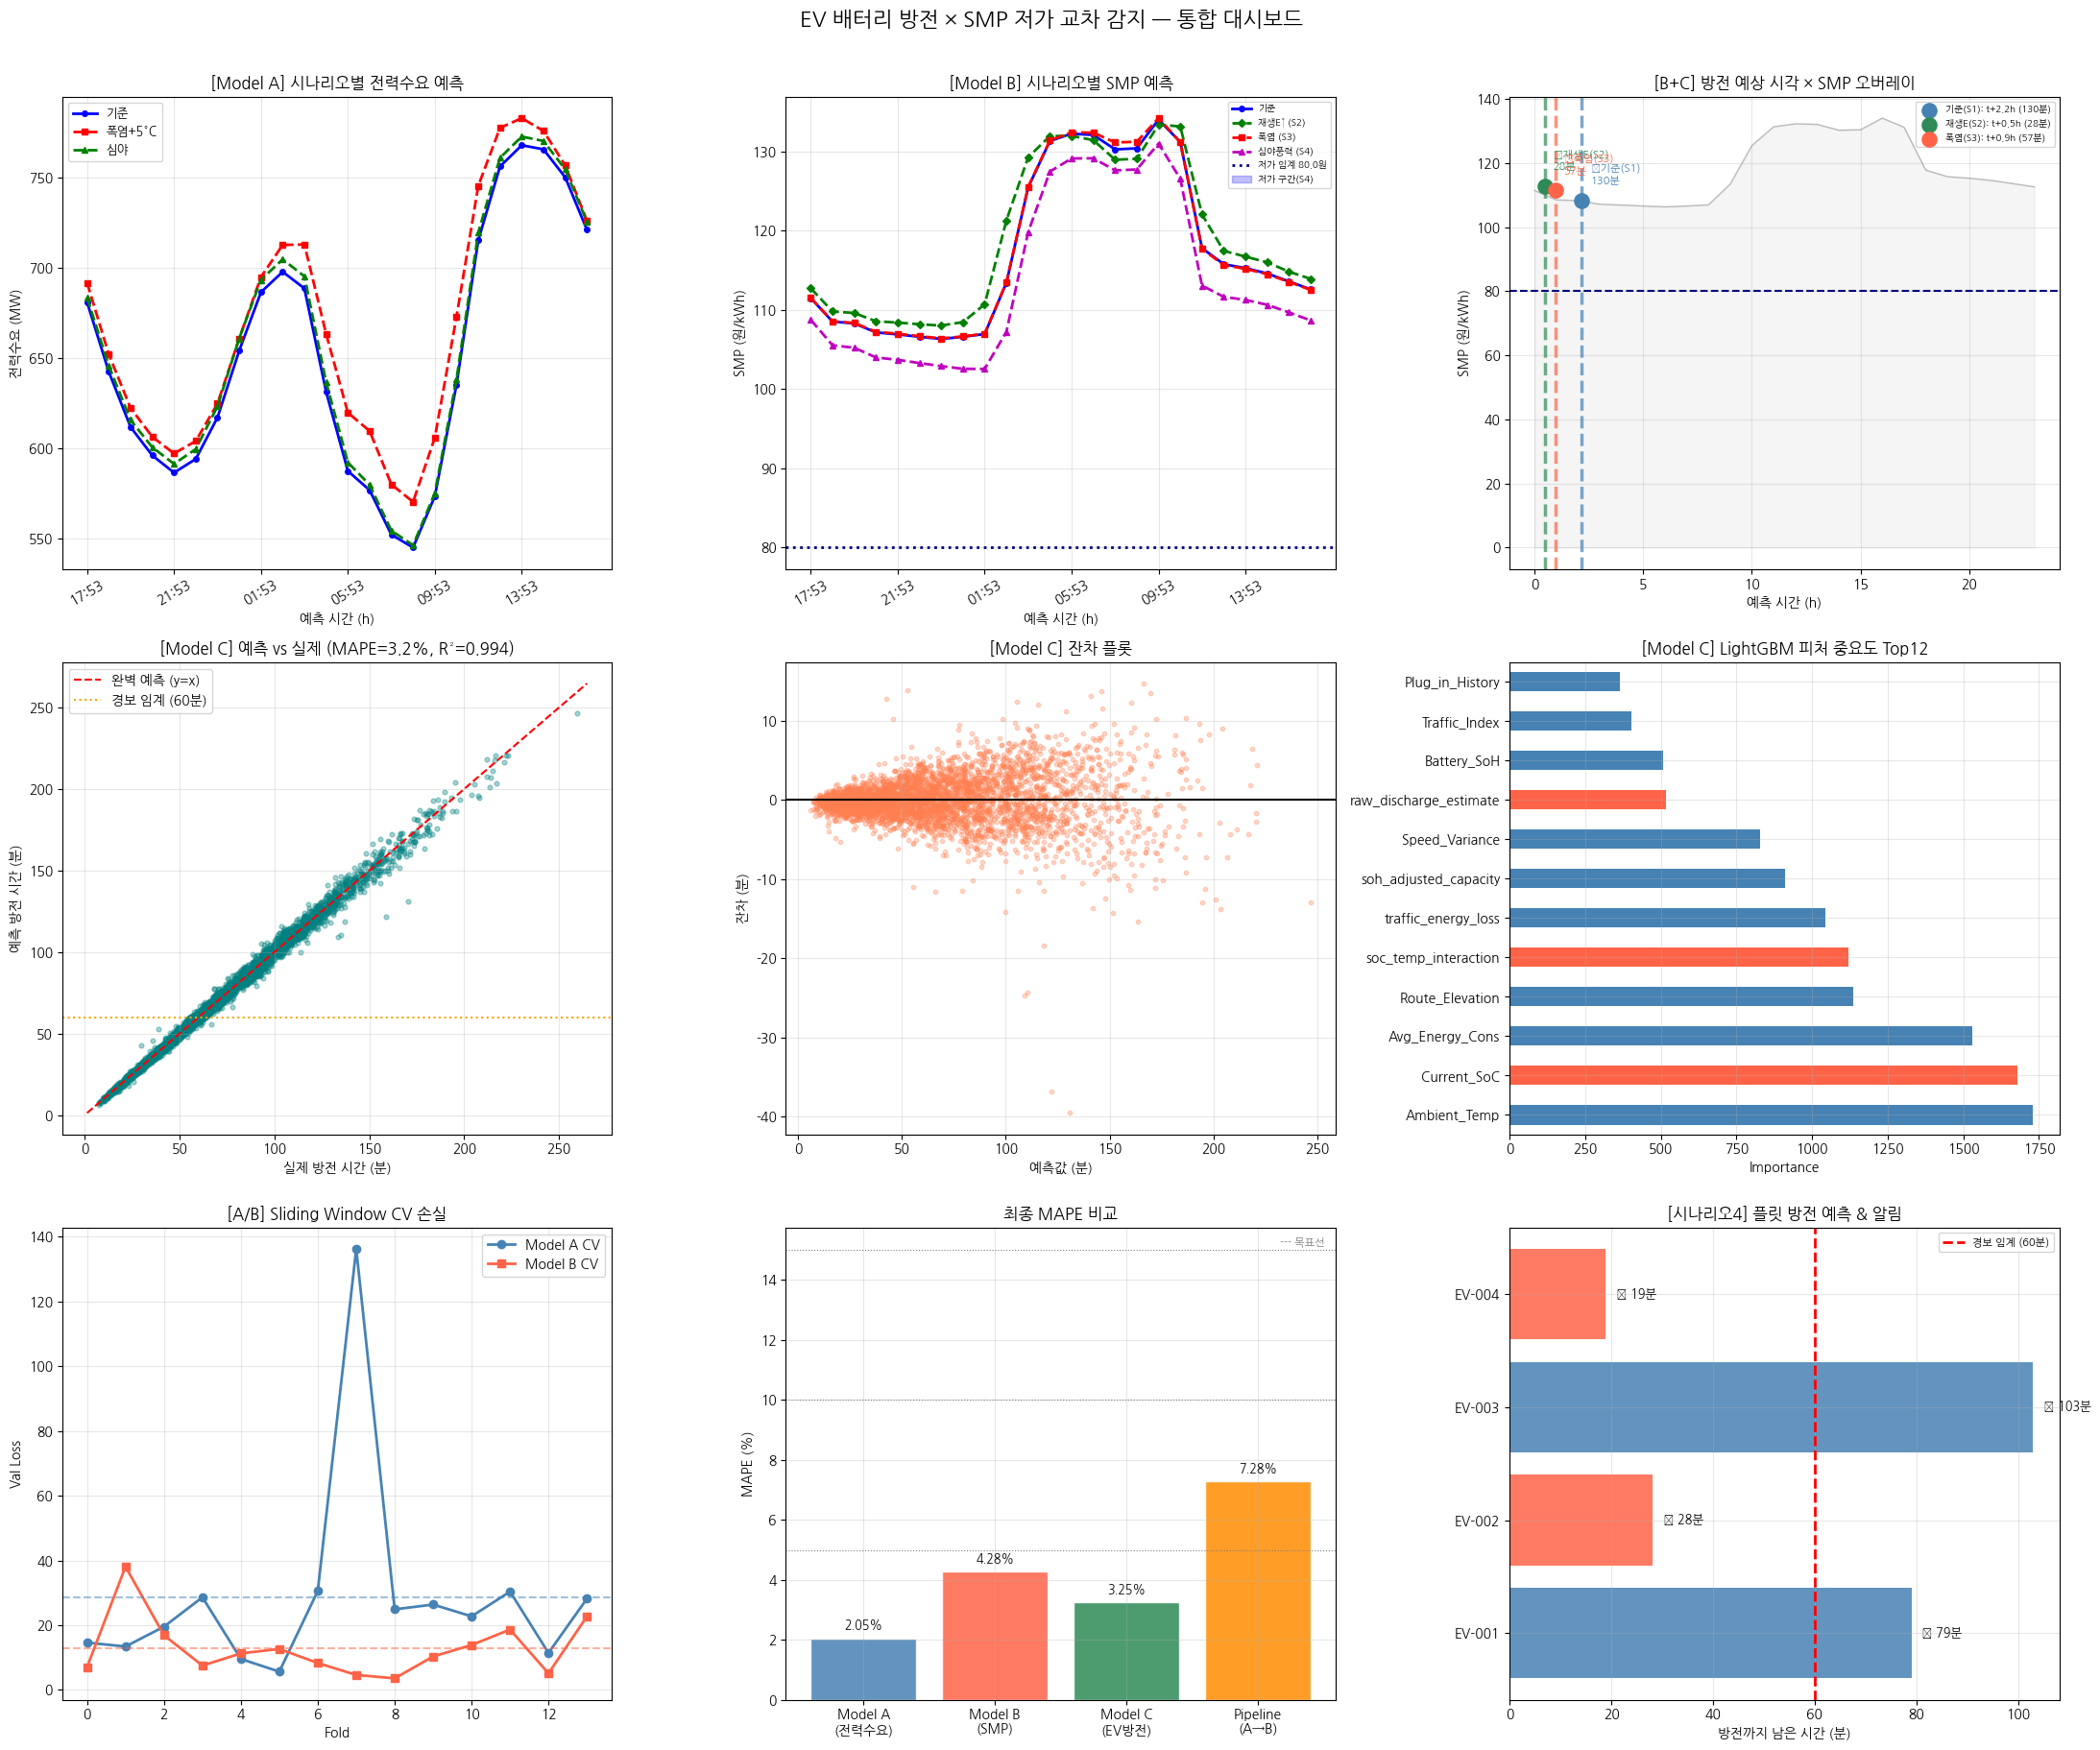

✅ 통합 대시보드 저장 완료


In [ ]:
fig = plt.figure(figsize=(22, 18))

hours = np.arange(Config.MAX_PRED_LEN)
hour_labels = [(current_time + timedelta(hours=int(h))).strftime('%H:%M') for h in hours]

# ── [Row 1] A, B 예측 비교 ──────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(hours, demand_base, 'b-o', ms=4, lw=2, label='기준')
ax1.plot(hours, demand_s3,   'r--s', ms=4, lw=2, label='폭염+5°C')
ax1.plot(hours, demand_s4,   'g--^', ms=4, lw=2, label='심야')
ax1.set_title('[Model A] 시나리오별 전력수요 예측', fontweight='bold')
ax1.set_xlabel('예측 시간 (h)'); ax1.set_ylabel('전력수요 (MW)')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_xticks(hours[::4])
ax1.set_xticklabels([hour_labels[h] for h in hours[::4]], rotation=30)

ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(hours, smp_base, 'b-o', ms=4, lw=2, label='기준')
ax2.plot(hours, smp_s2,   'g--D', ms=4, lw=2, label='재생E↑ (S2)')
ax2.plot(hours, smp_s3,   'r--s', ms=4, lw=2, label='폭염 (S3)')
ax2.plot(hours, smp_s4,   'm--^', ms=4, lw=2, label='심야풍력 (S4)')
ax2.axhline(Config.SMP_LOW_THRESHOLD, color='navy', lw=2, linestyle=':',
            label=f'저가 임계 {Config.SMP_LOW_THRESHOLD}원')
ax2.fill_between(hours, smp_s4, Config.SMP_LOW_THRESHOLD,
                 where=(smp_s4 < Config.SMP_LOW_THRESHOLD),
                 alpha=0.25, color='blue', label='저가 구간(S4)')
ax2.set_title('[Model B] 시나리오별 SMP 예측', fontweight='bold')
ax2.set_xlabel('예측 시간 (h)'); ax2.set_ylabel('SMP (원/kWh)')
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)
ax2.set_xticks(hours[::4])
ax2.set_xticklabels([hour_labels[h] for h in hours[::4]], rotation=30)

# ── [Row 1, Col 3] 방전 타임라인 ───────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
scenarios = {'기준(S1)': detail_s1, '재생E(S2)': detail_s2,
             '폭염(S3)': detail_s3}
smp_scenarios = {'기준(S1)': smp_base, '재생E(S2)': smp_s2, '폭염(S3)': smp_s3}
colors_sc = ['steelblue', 'seagreen', 'tomato']

# SMP 예측을 배경으로
ax3.fill_between(hours, smp_base, alpha=0.08, color='gray')
ax3.plot(hours, smp_base, 'gray', lw=1, alpha=0.5)
ax3.axhline(Config.SMP_LOW_THRESHOLD, color='navy', lw=1.5, linestyle='--')

for i, (name, det) in enumerate(scenarios.items()):
    dh = det['discharge_hour']
    smp_at = det['smp_at_discharge_h']
    color = colors_sc[i]
    marker = '🔴' if det['alert'] else '🟢'
    ax3.axvline(dh, color=color, lw=2.5, linestyle='--', alpha=0.7)
    ax3.scatter(dh, smp_at, s=120, color=color, zorder=5,
                label=f"{name}: t+{dh:.1f}h ({det['discharge_min']:.0f}분)")
    ax3.annotate(f"{marker}{name}\n{det['discharge_min']:.0f}분",
                 xy=(dh, smp_at), xytext=(dh+0.4, smp_at+5),
                 fontsize=8, color=color)

ax3.set_title('[B+C] 방전 예상 시각 × SMP 오버레이', fontweight='bold')
ax3.set_xlabel('예측 시간 (h)'); ax3.set_ylabel('SMP (원/kWh)')
ax3.legend(fontsize=7); ax3.grid(True, alpha=0.3)

# ── [Row 2] Model C 분석 ────────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
ax4.scatter(y_test_c, pred_c, alpha=0.35, s=12, color='teal')
lim = [min(y_test_c.min(), pred_c.min())-5, max(y_test_c.max(), pred_c.max())+5]
ax4.plot(lim, lim, 'r--', lw=1.5, label='완벽 예측 (y=x)')
ax4.axhline(Config.DISCHARGE_WARN_MIN, color='orange', linestyle=':', lw=1.5,
            label=f'경보 임계 ({Config.DISCHARGE_WARN_MIN}분)')
ax4.set_title(f'[Model C] 예측 vs 실제 (MAPE={mape_c:.1f}%, R²={r2_c:.3f})', fontweight='bold')
ax4.set_xlabel('실제 방전 시간 (분)'); ax4.set_ylabel('예측 방전 시간 (분)')
ax4.legend(); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(3, 3, 5)
residuals = pred_c - y_test_c.values
ax5.scatter(pred_c, residuals, alpha=0.3, s=10, color='coral')
ax5.axhline(0, color='black', lw=1.5)
ax5.set_title('[Model C] 잔차 플롯', fontweight='bold')
ax5.set_xlabel('예측값 (분)'); ax5.set_ylabel('잔차 (분)')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(3, 3, 6)
best_lgb_c.fit(X_train_cs, y_train_c)
fi_c = pd.Series(best_lgb_c.feature_importances_, index=X_train_cs.columns).nlargest(12)
colors_fi = ['tomato' if 'soc' in c.lower() or 'discharge' in c.lower()
             else 'steelblue' for c in fi_c.index]
fi_c.plot(kind='barh', ax=ax6, color=colors_fi)
ax6.set_title('[Model C] LightGBM 피처 중요도 Top12', fontweight='bold')
ax6.set_xlabel('Importance'); ax6.grid(True, alpha=0.3)

# ── [Row 3] CV 성능 & 플릿 알림 ─────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
ax7.plot(cv_scores_a, 'o-', color='steelblue', lw=2, label='Model A CV')
ax7.plot(cv_scores_b, 's-', color='tomato', lw=2, label='Model B CV')
ax7.axhline(np.nanmean(cv_scores_a), color='steelblue', linestyle='--', alpha=0.5)
ax7.axhline(np.nanmean(cv_scores_b), color='tomato',    linestyle='--', alpha=0.5)
ax7.set_title('[A/B] Sliding Window CV 손실', fontweight='bold')
ax7.set_xlabel('Fold'); ax7.set_ylabel('Val Loss')
ax7.legend(); ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(3, 3, 8)
labels  = ['Model A\n(전력수요)','Model B\n(SMP)','Model C\n(EV방전)','Pipeline\n(A→B)']
values  = [mape_a, mape_b, mape_c, pipe_mape]
targets = [5, 10, 15, None]
bar_colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
bars = ax8.bar(labels, values, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val, tgt in zip(bars, values, targets):
    ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
    if tgt:
        ax8.axhline(tgt, color='gray', lw=0.8, linestyle=':')
ax8.set_title('최종 MAPE 비교', fontweight='bold')
ax8.set_ylabel('MAPE (%)')
ax8.text(0.98, 0.98, '--- 목표선', transform=ax8.transAxes,
         ha='right', va='top', color='gray', fontsize=8)
ax8.grid(True, alpha=0.3)

ax9 = fig.add_subplot(3, 3, 9)
# 플릿 알림 시각화 (시나리오 4)
fleet_ids = [r['id'] for r in fleet_results]
fleet_dm  = [r['discharge_min'] for r in fleet_results]
fleet_alert = [r['alert'] for r in fleet_results]
fleet_colors = ['tomato' if a else 'steelblue' for a in fleet_alert]
bars_f = ax9.barh(fleet_ids, fleet_dm, color=fleet_colors, alpha=0.85)
ax9.axvline(Config.DISCHARGE_WARN_MIN, color='red', lw=2, linestyle='--',
            label=f'경보 임계 ({Config.DISCHARGE_WARN_MIN}분)')
for bar, dm, a in zip(bars_f, fleet_dm, fleet_alert):
    emoji = '🚨' if a else '✅'
    ax9.text(dm + 2, bar.get_y() + bar.get_height()/2,
             f'{emoji} {dm:.0f}분', va='center', fontsize=9)
# SMP 저가 구간 표시 (시간 → 분 환산)
low_windows_s4 = detect_smp_low_windows(smp_s4)
for ws, we in low_windows_s4:
    ax9.axvspan(ws*60, we*60, alpha=0.12, color='blue',
                label=f'SMP저가 {ws}h~{we}h' if ws == low_windows_s4[0][0] else '')
ax9.set_title('[시나리오4] 플릿 방전 예측 & 알림', fontweight='bold')
ax9.set_xlabel('방전까지 남은 시간 (분)')
ax9.legend(fontsize=8); ax9.grid(True, alpha=0.3)

plt.suptitle('EV 배터리 방전 × SMP 저가 교차 감지 — 통합 대시보드',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(Config.SAVE_PATH, 'integrated_dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ 통합 대시보드 저장 완료")

---
## 9. XAI — SHAP 기반 Model C 해석 + TFT Attention

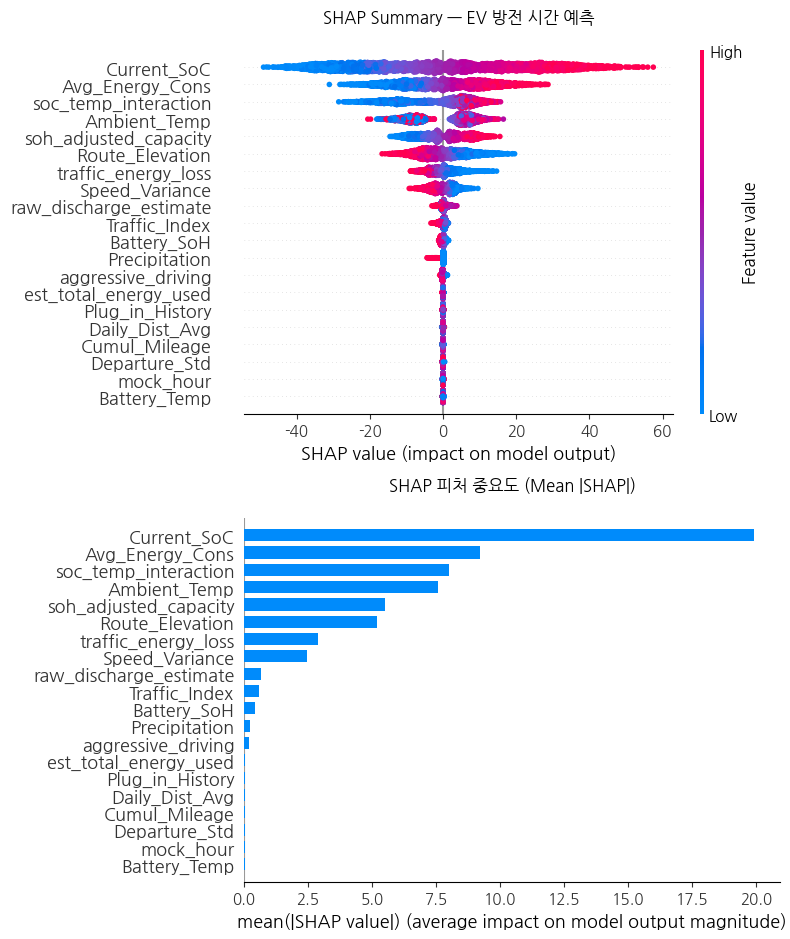

💡 [AI 통합 설명 시스템]
   배터리가 10%에 도달하기까지 약 19분이 예측됩니다.
   ⚠️  Current_SoC 수치(-1.13)가 방전 시간을 단축시키는 주요 요인입니다.
   ✅  Avg_Energy_Cons 수치(1.74)는 배터리 지속에 긍정적 영향을 미칩니다.
   🚨  방전 시점과 저가 구간이 겹치므로, 지금 충전을 강력 권고합니다.


In [ ]:
# ── SHAP — Model C (LightGBM Base) ─────────────────────────────────────────
explainer_c   = shap.TreeExplainer(best_lgb_c)
shap_values_c = explainer_c.shap_values(X_test_cs)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# 첫 번째 그래프 (axes[0])
plt.sca(axes[0])
shap.summary_plot(shap_values_c, X_test_cs, plot_type='dot', show=False)
axes[0].set_title('SHAP Summary — EV 방전 시간 예측', fontweight='bold', pad=20)

# 두 번째 그래프 (axes[1])
plt.sca(axes[1])
shap.summary_plot(shap_values_c, X_test_cs, plot_type='bar', show=False)
axes[1].set_title('SHAP 피처 중요도 (Mean |SHAP|)', fontweight='bold', pad=20)

# 그래프 간 간격 확보
plt.tight_layout()
plt.show()

# ── 자연어 설명 생성 ────────────────────────────────────────────────────────
def generate_nlp_explanation_c(feature_names, shap_vals, data_vals,
                                discharge_min, alert_flag, smp_arr):
    impacts  = list(zip(feature_names, shap_vals, data_vals))
    impacts.sort(key=lambda x: abs(x[1]), reverse=True)
    neg = [f for f in impacts if f[1] < -0.5][:2]
    pos = [f for f in impacts if f[1] > 0.5][:2]
    low_windows = detect_smp_low_windows(smp_arr)

    text = "💡 [AI 통합 설명 시스템]\n"
    text += f"   배터리가 10%에 도달하기까지 약 {discharge_min:.0f}분이 예측됩니다.\n"
    if neg:
        text += (f"   ⚠️  {neg[0][0]} 수치({neg[0][2]:.2f})가 방전 시간을 단축시키는 "
                 f"주요 요인입니다.\n")
    if pos:
        text += (f"   ✅  {pos[0][0]} 수치({pos[0][2]:.2f})는 배터리 지속에 "
                 f"긍정적 영향을 미칩니다.\n")
    if low_windows:
        text += f"   📉  SMP 저가 구간: "
        text += ', '.join([f"t+{ws}h~t+{we}h" for ws, we in low_windows])
        text += '\n'
    if alert_flag:
        text += "   🚨  방전 시점과 저가 구간이 겹치므로, 지금 충전을 강력 권고합니다."
    else:
        text += "   ✅  현재 긴급 충전 필요 없음. 저가 구간에 맞춰 충전 예약을 권장합니다."
    return text

# 방전 임박 차량(EV-004 프로파일) 설명
ev_sample = fleet[3]   # EV-004
ev_sample.pop('id', None)
sample_input_df = pd.DataFrame(
    [{col: ev_sample.get(col, 0.0) for col in X_c.columns}])
# 파생 피처 재계산
fe_temp = feature_engineering_c(pd.concat([df_c_raw.head(1), sample_input_df],
                                           ignore_index=True)).iloc[[1]]
fe_temp = fe_temp.drop(Config.TARGET_C, axis=1, errors='ignore')[X_c.columns]
fe_scaled = pd.DataFrame(scaler_c.transform(fe_temp), columns=X_c.columns)
shap_single = explainer_c.shap_values(fe_scaled)[0]

dm_sample = predict_discharge_time(stacking_c, scaler_c, ev_sample)
alert_sample, _ = check_overlap_and_alert(dm_sample, smp_s4, current_time, verbose=False)

print(generate_nlp_explanation_c(
    X_c.columns, shap_single, fe_scaled.values[0],
    dm_sample, alert_sample, smp_s4))

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

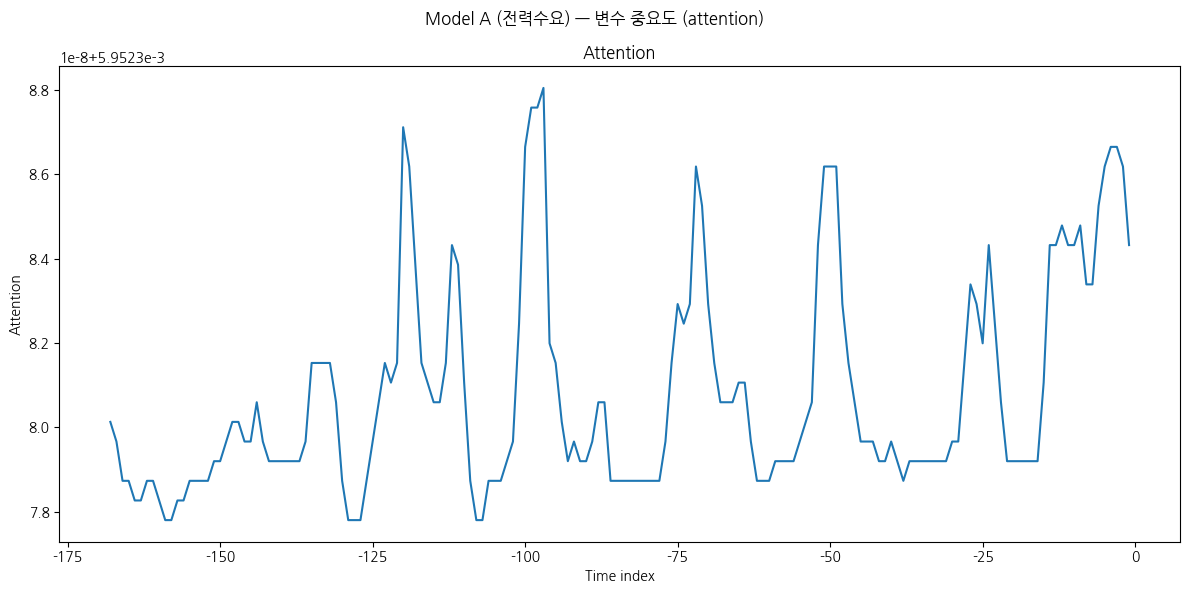

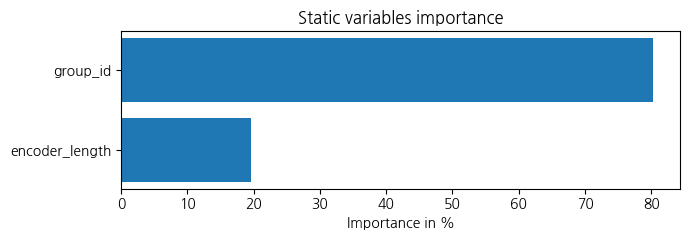

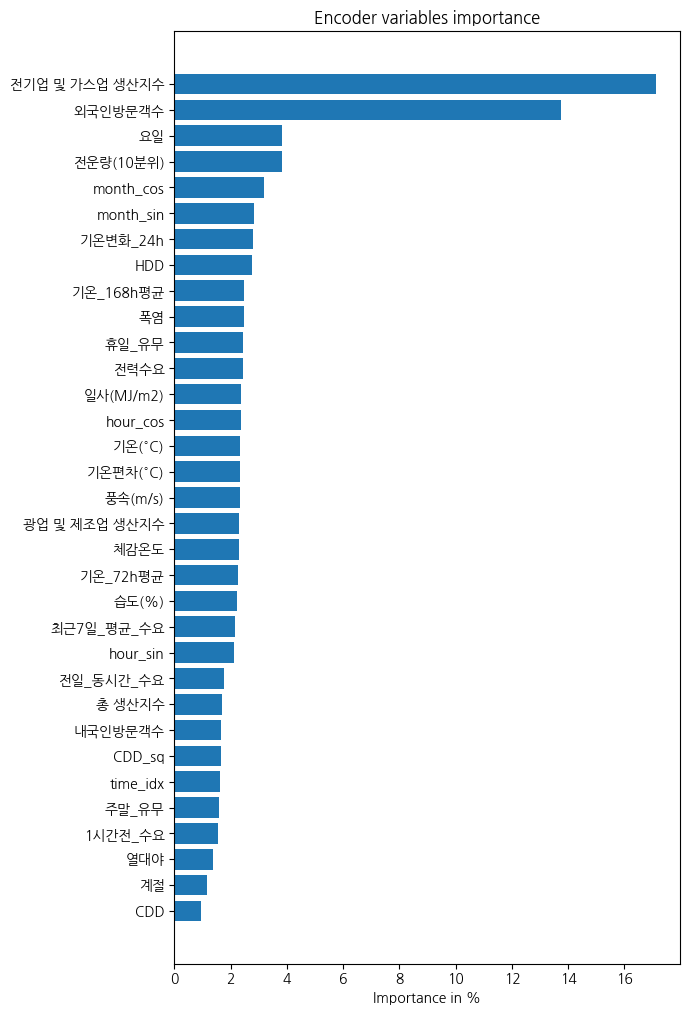

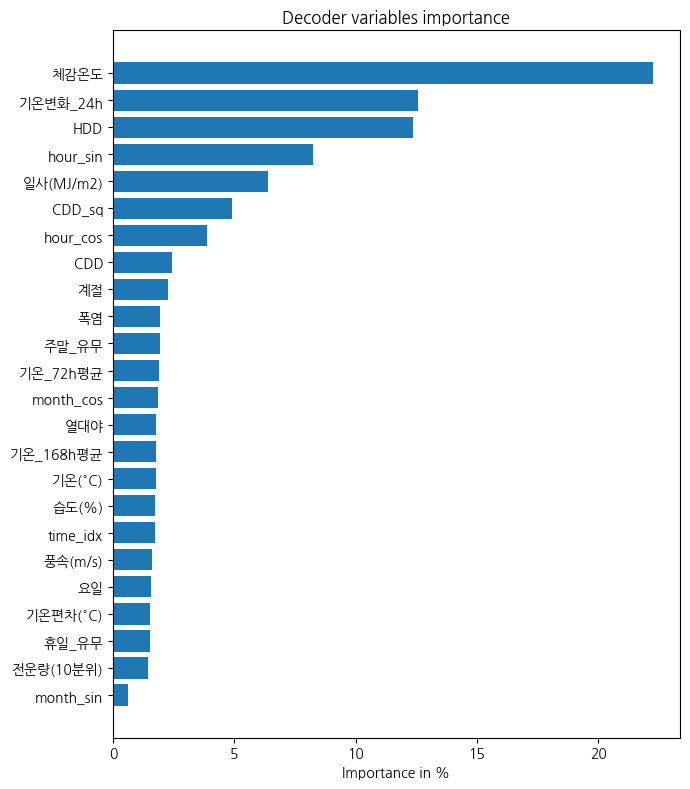

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

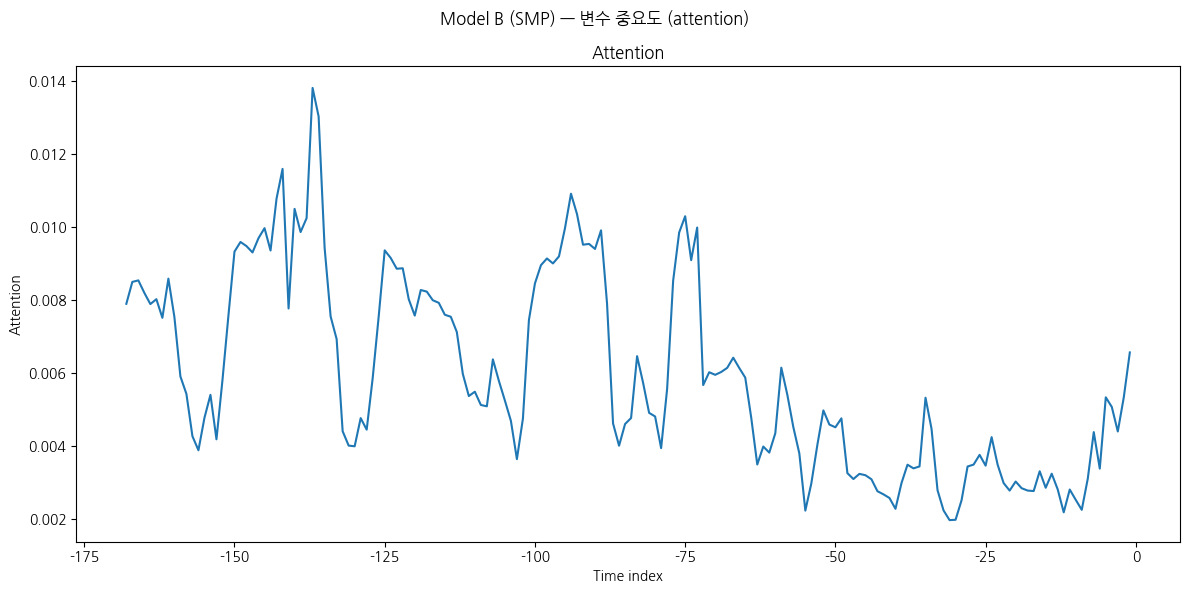

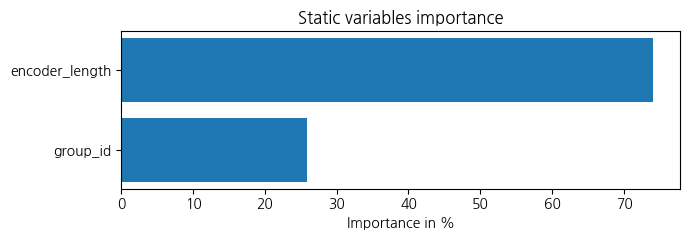

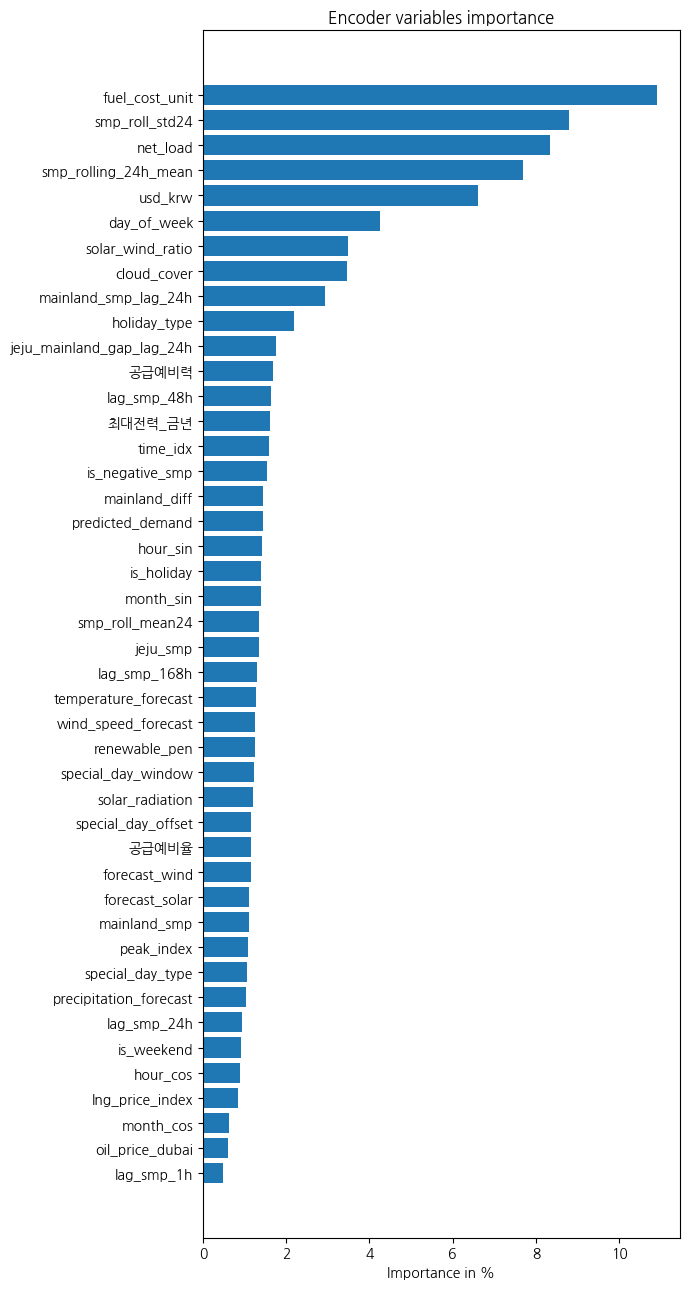

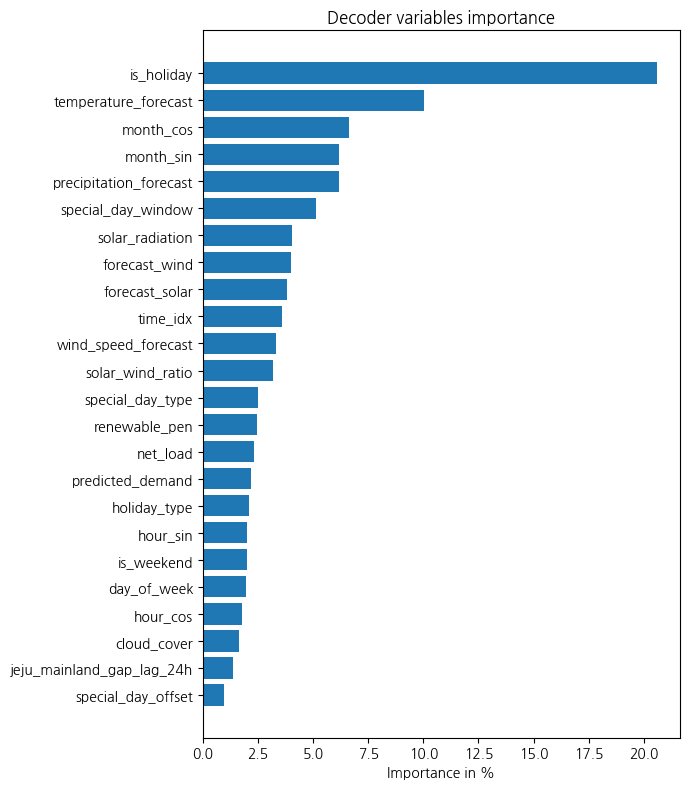

In [ ]:
# ── TFT Attention — Model B (SMP 예측) 해석 ─────────────────────────────────
try:
    for model, dl, name in [
        (tft_a, val_dl_a, 'Model A (전력수요)'),
        (tft_b, val_dl_b, 'Model B (SMP)')]:
        raw    = model.predict(dl, mode='raw', return_x=True)
        interp = model.interpret_output(raw.output, reduction='sum')
        figs   = model.plot_interpretation(interp)
        for key, fig in figs.items():
            fig.suptitle(f'{name} — 변수 중요도 ({key})', fontsize=12, fontweight='bold')
            fig.tight_layout()
            plt.show()
except Exception as e:
    print(f"TFT Attention 시각화 오류: {e}")

---
## 10. 고급 분석 — EV 운전자 군집 × SMP 저가 패턴 매칭

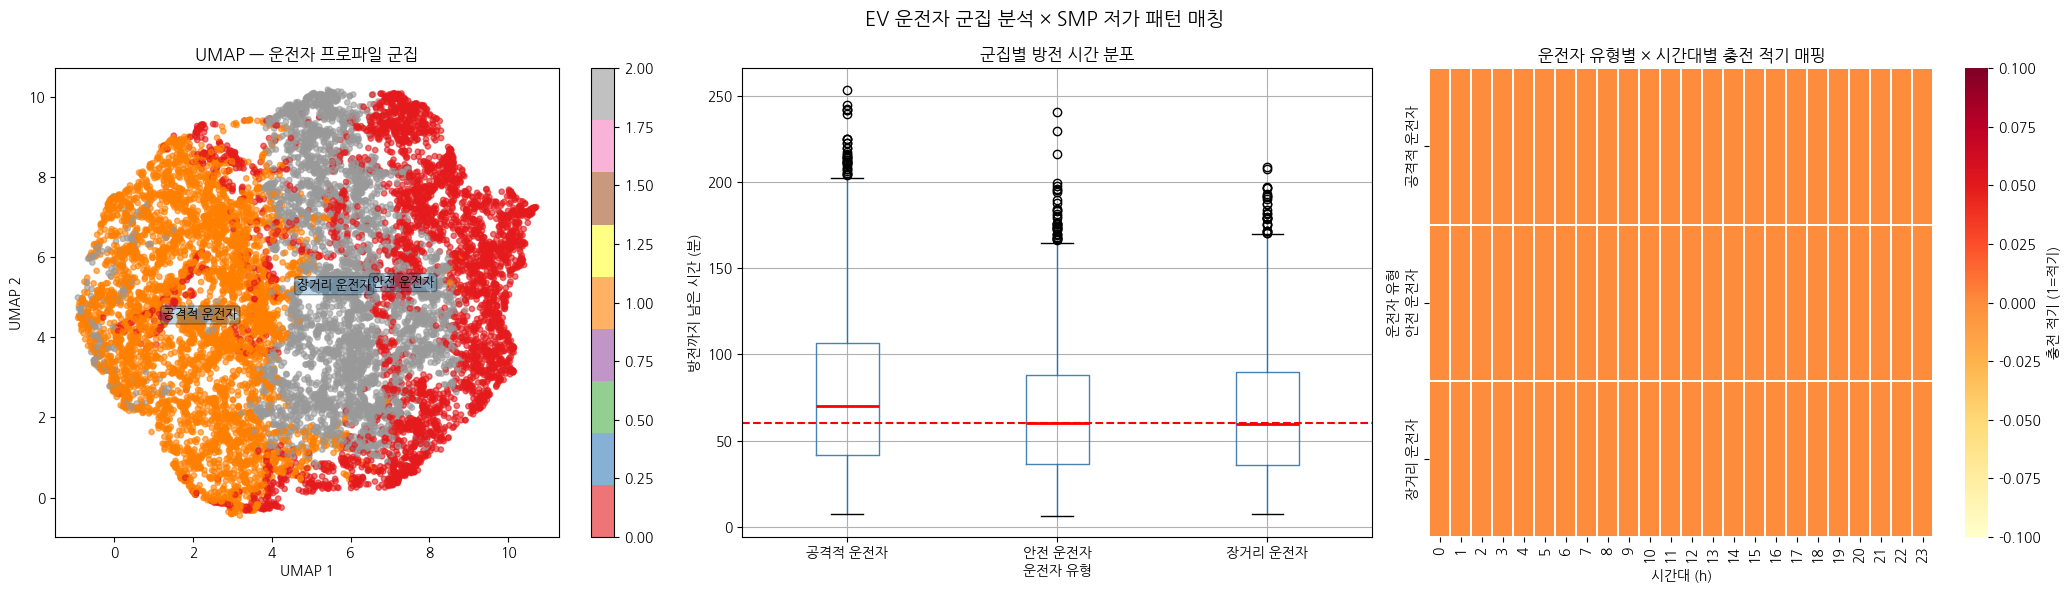


[군집별 방전 시간 통계]
                   mean        std  median
cluster_name                              
공격적 운전자       77.596201  44.072012    69.9
안전 운전자        65.202881  36.119497    60.4
장거리 운전자       65.796014  37.210618    59.7


In [ ]:
# ── 운전자 군집 분석 ──────────────────────────────────────────────────────
cluster_feats = ['Speed_Variance', 'Avg_Energy_Cons', 'Departure_Std',
                 'Daily_Dist_Avg', 'Route_Elevation']
X_cl = X_train_cs[cluster_feats]

kmeans_c = KMeans(n_clusters=3, random_state=Config.SEED)
clusters = kmeans_c.fit_predict(X_cl)

cluster_labels = {0: '안전 운전자', 1: '공격적 운전자', 2: '장거리 운전자'}

# 클러스터별 방전 시간 분포
cluster_df = pd.DataFrame({
    'cluster_id': clusters,
    'cluster_name': [cluster_labels[c] for c in clusters],
    'discharge_min': y_train_c.values
})

# UMAP 임베딩
reducer = umap.UMAP(random_state=Config.SEED, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_cl)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# UMAP
scatter = axes[0].scatter(embedding[:, 0], embedding[:, 1],
                          c=clusters, cmap='Set1', s=15, alpha=0.6)
plt.colorbar(scatter, ax=axes[0])
axes[0].set_title('UMAP — 운전자 프로파일 군집', fontweight='bold')
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
for ci, label in cluster_labels.items():
    mask = clusters == ci
    cx, cy = embedding[mask, 0].mean(), embedding[mask, 1].mean()
    axes[0].annotate(label, (cx, cy), fontsize=9, fontweight='bold',
                     ha='center', bbox=dict(boxstyle='round,pad=0.2', alpha=0.3))

# 군집별 방전 시간 박스플롯
cluster_df.boxplot(column='discharge_min', by='cluster_name', ax=axes[1],
                   boxprops=dict(color='steelblue'), medianprops=dict(color='red', lw=2))
axes[1].axhline(Config.DISCHARGE_WARN_MIN, color='red', lw=1.5, linestyle='--',
                label=f'경보 임계 {Config.DISCHARGE_WARN_MIN}분')
axes[1].set_title('군집별 방전 시간 분포', fontweight='bold')
axes[1].set_xlabel('운전자 유형'); axes[1].set_ylabel('방전까지 남은 시간 (분)')
plt.sca(axes[1]); plt.suptitle('')

# SMP 저가 시간대 × 군집별 충전 필요도 히트맵
smp_hourly = df_b.groupby(df_b['datetime'].dt.hour)['jeju_smp'].mean()
cluster_avg_dm = cluster_df.groupby('cluster_name')['discharge_min'].mean()
heatmap_data = pd.DataFrame({
    name: [1 if (dm/60 > h and smp_hourly.get(h, 100) < Config.SMP_LOW_THRESHOLD) else 0
           for h in range(24)]
    for name, dm in cluster_avg_dm.items()
}, index=range(24))

sns.heatmap(heatmap_data.T, ax=axes[2], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': '충전 적기 (1=적기)'})
axes[2].set_title('운전자 유형별 × 시간대별 충전 적기 매핑', fontweight='bold')
axes[2].set_xlabel('시간대 (h)'); axes[2].set_ylabel('운전자 유형')

plt.suptitle('EV 운전자 군집 분석 × SMP 저가 패턴 매칭', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[군집별 방전 시간 통계]")
print(cluster_df.groupby('cluster_name')['discharge_min'].agg(['mean','std','median']))

---
## 11. 학습 곡선 및 Optuna 수렴 시각화

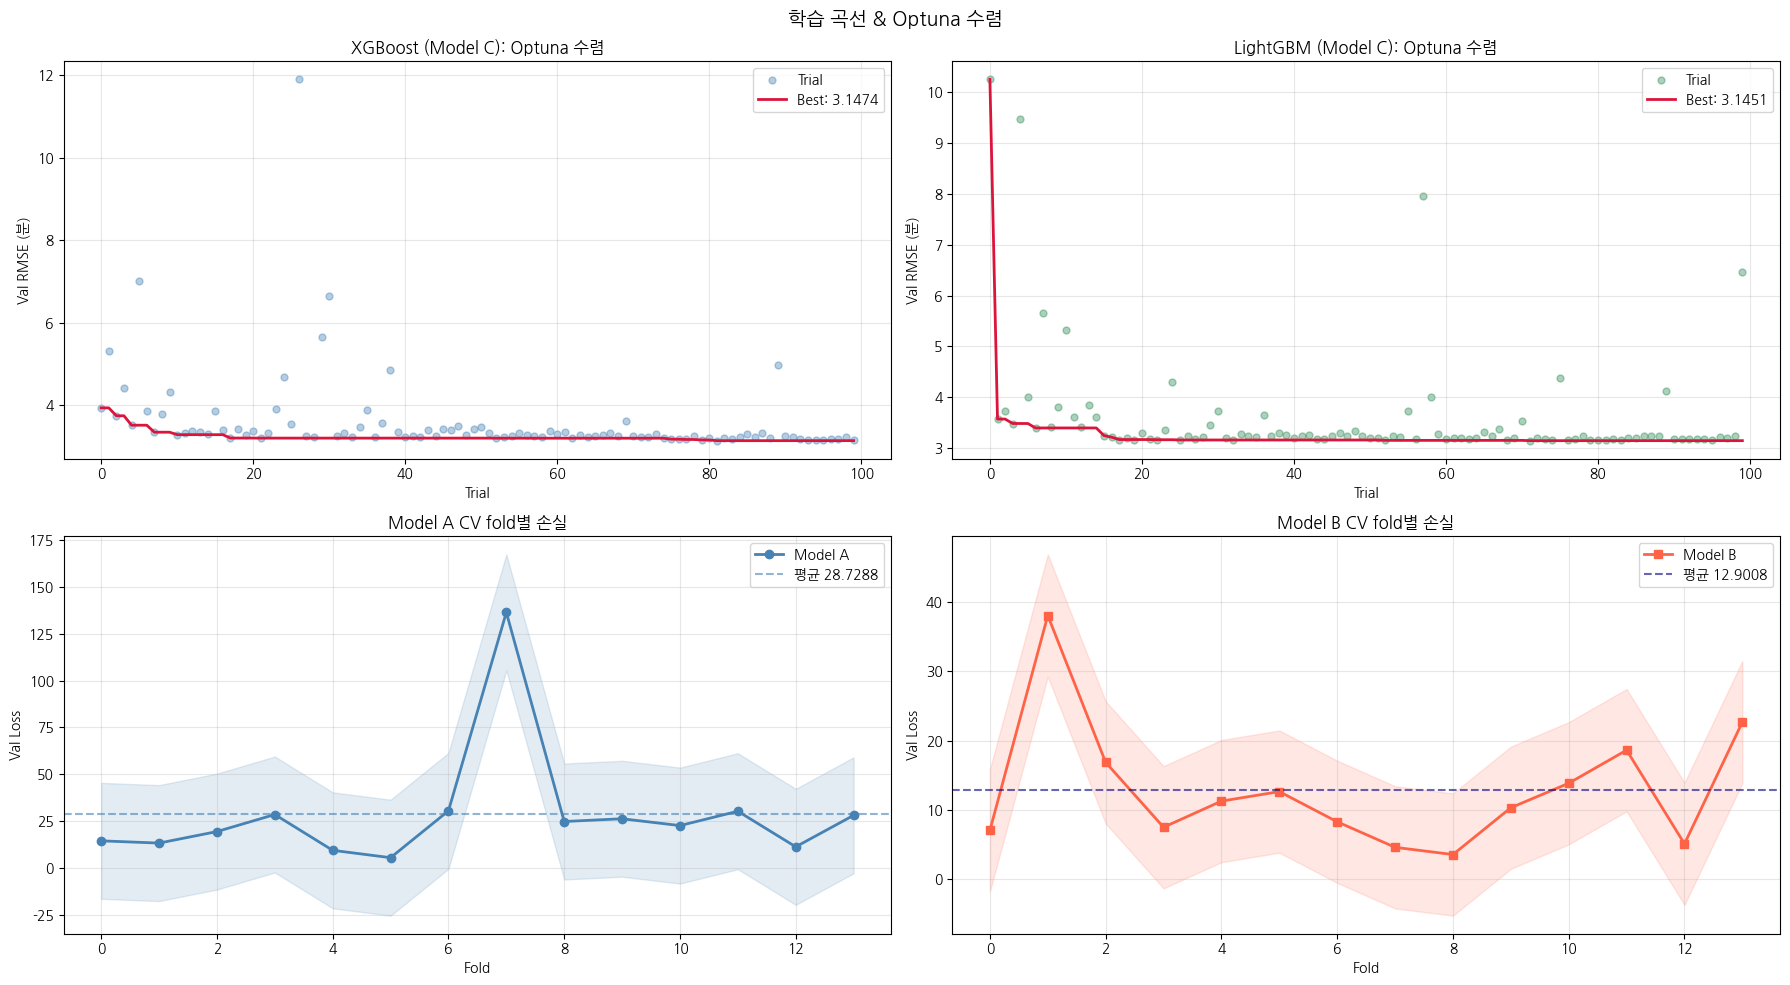

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ── Optuna 수렴 곡선 (XGB, LGB for Model C) ─────────────────────────────────
for ax, (study, name, color) in zip(axes[0], [
    (study_xgb_c, 'XGBoost (Model C)', 'steelblue'),
    (study_lgb_c, 'LightGBM (Model C)', 'seagreen')]):
    trial_vals  = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(trial_vals)
    ax.scatter(range(len(trial_vals)), trial_vals, alpha=0.4, s=25, color=color, label='Trial')
    ax.plot(best_so_far, color='crimson', lw=2, label=f'Best: {min(trial_vals):.4f}')
    ax.set_title(f'{name}: Optuna 수렴', fontweight='bold')
    ax.set_xlabel('Trial'); ax.set_ylabel('Val RMSE (분)')
    ax.legend(); ax.grid(True, alpha=0.3)

# ── CV 스코어 비교 ──────────────────────────────────────────────────────────
axes[1][0].plot(cv_scores_a, 'o-', color='steelblue', lw=2, label='Model A')
axes[1][0].fill_between(range(len(cv_scores_a)),
    np.array(cv_scores_a) - np.nanstd(cv_scores_a),
    np.array(cv_scores_a) + np.nanstd(cv_scores_a),
    alpha=0.15, color='steelblue')
axes[1][0].axhline(np.nanmean(cv_scores_a), color='steelblue', linestyle='--', alpha=0.6,
                   label=f'평균 {np.nanmean(cv_scores_a):.4f}')
axes[1][0].set_title('Model A CV fold별 손실', fontweight='bold')
axes[1][0].set_xlabel('Fold'); axes[1][0].set_ylabel('Val Loss')
axes[1][0].legend(); axes[1][0].grid(True, alpha=0.3)

axes[1][1].plot(cv_scores_b, 's-', color='tomato', lw=2, label='Model B')
axes[1][1].fill_between(range(len(cv_scores_b)),
    np.array(cv_scores_b) - np.nanstd(cv_scores_b),
    np.array(cv_scores_b) + np.nanstd(cv_scores_b),
    alpha=0.15, color='tomato')
axes[1][1].axhline(np.nanmean(cv_scores_b), color='navy', linestyle='--', alpha=0.6,
                   label=f'평균 {np.nanmean(cv_scores_b):.4f}')
axes[1][1].set_title('Model B CV fold별 손실', fontweight='bold')
axes[1][1].set_xlabel('Fold'); axes[1][1].set_ylabel('Val Loss')
axes[1][1].legend(); axes[1][1].grid(True, alpha=0.3)

plt.suptitle('학습 곡선 & Optuna 수렴', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. 최종 요약 & 모델 저장

In [ ]:
# ── 최종 요약 출력 ─────────────────────────────────────────────────────────
# ✅ loaded_a / loaded_b 중복 로드 제거 (섹션 7에서 이미 tft_a, tft_b 교체 완료)

print("=" * 68)
print("               A × B × C 통합 파이프라인 최종 성능 요약")
print("=" * 68)
print(f"{'항목':<35} {'값':>10}    기준")
print("-" * 68)
print(f"{'[Model A] 전력수요 MAPE':<35} {mape_a:>9.2f}%   ≤ 5%  {status_a}")
print(f"{'[Model A] RMSE':<35} {rmse_a:>10.2f}")
print(f"{'[Model A] CV 평균 Loss':<35} {np.nanmean(cv_scores_a):>10.4f}")
print("-" * 68)
print(f"{'[Model B] SMP MAPE':<35} {mape_b:>9.2f}%   ≤ 10% {status_b}")
print(f"{'[Model B] RMSE':<35} {rmse_b:>10.2f}")
print(f"{'[Model B] CV 평균 Loss':<35} {np.nanmean(cv_scores_b):>10.4f}")
print("-" * 68)
print(f"{'[Model C] EV 방전 시간 MAPE':<35} {mape_c:>9.2f}%   ≤ 15% {status_c}")
print(f"{'[Model C] RMSE':<35} {rmse_c:>10.2f}  분")
print(f"{'[Model C] MAE':<35} {mae_c:>10.2f}  분")
print(f"{'[Model C] R²':<35} {r2_c:>10.4f}")
print("-" * 68)
print(f"{'[Pipeline A→B] MAPE':<35} {pipe_mape:>9.2f}%   운영 성능")
print(f"{'A 오차 전파':<35} {pipe_mape - mape_b:>+9.2f}%p")
print("=" * 68)
print()
print("[🎯 핵심 시나리오 결과]")
for name, det, smp in [
    ('시나리오1 기준', detail_s1, smp_base),
    ('시나리오2 재생E↑', detail_s2, smp_s2),
    ('시나리오3 폭염', detail_s3, smp_s3)]:
    emoji = '🚨' if det['alert'] else '✅'
    print(f"  {emoji} {name:<20} | 방전:{det['discharge_min']:>6.0f}분 "
          f"| SMP저가 교차: {'있음' if det['overlap'] else '없음'} "
          f"| 알림: {'발생' if det['alert'] else '없음'}")
print()
print(f"[🚗 플릿 알림 현황 (시나리오4 — 심야 재생E 과잉)]")
for r in fleet_results:
    emoji = '🚨' if r['alert'] else '✅'
    print(f"  {emoji} {r['id']}: 방전 {r['detail']['discharge_min']:.0f}분 후 "
          f"| 저가 교차: {'O' if r['detail']['overlap'] else 'X'} "
          f"| 알림: {'발생' if r['alert'] else '없음'}")
print("=" * 68)
print("✅ 통합 파이프라인 완료")


               A × B × C 통합 파이프라인 최종 성능 요약
항목                                           값    기준
--------------------------------------------------------------------
[Model A] 전력수요 MAPE                      2.05%   ≤ 5%  ✅
[Model A] RMSE                           15.91
[Model A] CV 평균 Loss                   28.7288
--------------------------------------------------------------------
[Model B] SMP MAPE                       4.28%   ≤ 10% ✅
[Model B] RMSE                            6.45
[Model B] CV 평균 Loss                   12.9008
--------------------------------------------------------------------
[Model C] EV 방전 시간 MAPE                  3.25%   ≤ 15% ✅
[Model C] RMSE                            3.15  분
[Model C] MAE                             2.17  분
[Model C] R²                            0.9939
--------------------------------------------------------------------
[Pipeline A→B] MAPE                      7.28%   운영 성능
A 오차 전파                                 +3.00%p

[🎯 핵심 시나리오 결과]
  ✅